## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import random

from scipy import stats
from scipy.stats import pearsonr
from wordfreq import zipf_frequency

from flow_tree_utils import (
    steiger_z_test,
    get_matched_random_walk,
    generate_flow_tree_from_trajs,
    plot_flow_tree,
)

### Load wikispeedia data, etc

In [2]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        article_names.append(line)
print(f"{len(article_names)} nodes/articles loaded.")

# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(
    f"{data_path}/links.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
print(f"{len(edges_df)} edges/hyperlinks loaded.")

wikiG = nx.DiGraph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))
print(wikiG)

4604 nodes/articles loaded.
119881 edges/hyperlinks loaded.
DiGraph with 4592 nodes and 119881 edges


In [3]:
### Load trajectories
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print(f"{trajs_df.shape[0]} trajectories before dupes removed")
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print(f"Final data has {trajs_df.shape[0]} trajectories")
print(
    f"\twith {len(trajs_df.StartAt.unique())} unique starts and {len(trajs_df.EndAt.unique())} unique ends"
)
print(f"\tand {len(trajs_df.hashedIpAddress.unique())} unique players")


def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "__" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]].head()

76193 trajectories before dupes removed
Final data has 70770 trajectories
	with 4168 unique starts and 3997 unique ends
	and 20868 unique players


,StartEnd,traj,accuracy,avg_rating
0,14th_century__African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century__African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century__African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century__Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century__John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0


## 2. Helper fns
to make below less gross

In [4]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

stop_words = set(["a", "an", "the", "and", "for", "of"])

node_indegrees = {}
node_outdegrees = {}
node_zipf_frequencies = {}
for node in node_counts:
    if node in wikiG:
        node_indegrees[node] = wikiG.in_degree(node)
        node_outdegrees[node] = wikiG.out_degree(node)
        node_zipf_frequencies[node] = np.mean(
            [
                zipf_frequency(word, "en")
                for word in node.split("_")
                if word not in stop_words
            ]
        )


# find most common nodes
def find_k_most_x_nodes(
    node_value_dict, k=100, restrict_to=None, actually_most=True, verbose_str=None
):
    if restrict_to is None:
        restrict_to = node_value_dict.keys()
    most_x_nodes = sorted(
        [x for x in restrict_to],
        key=lambda x: node_value_dict[x],
        reverse=actually_most,
    )[:k]

    if verbose_str:
        print(
            f"{'Most' if actually_most else 'Least'} {verbose_str} node is {most_x_nodes[0]} with {node_value_dict[most_x_nodes[0]]}; "
            f"{k}th {'most' if actually_most else 'least'} is {most_x_nodes[-1]} with {node_value_dict[most_x_nodes[-1]]}"
        )
    return most_x_nodes

In [5]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# pip install "tokenizers<0.22" --force-reinstall
model_name = "bert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


def embed(text):
    tokens = tok(text.replace("_", " "), return_tensors="pt", truncation=True)
    out = model(**tokens)
    # mean pooling
    emb = out.last_hidden_state.mean(dim=1)
    return emb.detach()


def cosine(a, b):
    return F.cosine_similarity(a, b).item()


def get_topic_distance(topic1, topic2):
    return cosine(embed(topic1), embed(topic2))


get_topic_distance("the_dog", "the_cat")

0.9181366562843323

In [6]:
embeddings_dict = {node: embed(node) for node in node_counts}

In [7]:
degree_cache = {}
zipf_cache = {}
cosine_cache = {}

In [8]:
def get_weighted_matched_random_walk(
    G, start_node, walk_length, weights, degree_cache=degree_cache
):
    trajectory = [start_node]
    current_node = start_node

    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))

        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        elif len(neighbors) == 1:
            current_node = neighbors[0]
        else:
            # if current_node in degree_cache:
            #     # print("using cache")
            #     these_weights = degree_cache[current_node]
            # else:
            # print("adding to cache", current_node)
            these_weights = [weights[n] for n in neighbors]
            # degree_cache[current_node] = these_weights
            try:
                current_node = random.choices(neighbors, these_weights, k=1)[0]
            except:
                print(these_weights)
        trajectory.append(current_node)

    return trajectory


def get_targeted_matched_random_walk(G, start_node, target, walk_length):
    trajectory = [start_node]
    current_node = start_node

    # print(start_node, target)
    # print(walk_length)

    # TODO: this should be based on similariyt to target youa re so stupid
    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))
        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        else:
            if current_node in cosine_cache:
                # print("using cache")
                weights = cosine_cache[current_node]
            else:
                weights = []
                for n in neighbors:
                    w1 = embeddings_dict.get(n, embed(n))
                    if n not in embeddings_dict:
                        embeddings_dict[n] = w1

                    w2 = embeddings_dict.get(current_node, embed(current_node))
                    if current_node not in embeddings_dict:
                        embeddings_dict[current_node] = w2
                    dist = cosine(w1, w2)
                    weights.append(dist)
                cosine_cache[current_node] = weights
                print("added to cache", current_node)

            current_node = random.choices(neighbors, weights, k=1)[0]
        trajectory.append(current_node)
    return trajectory

In [43]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

word_frequency_centrality = {}
for node in wikiG.nodes():
    word_frequency_centrality[node] = np.mean(
        [zipf_frequency(word, "en") for word in node.split("_")]
    )
print("Word Frequency Centrality:", word_frequency_centrality)

# takes ~15 sec to run
closeness_centrality = nx.closeness_centrality(wikiG)
print("Closeness_centrality:", closeness_centrality)

# takes a minute or so
betweenness_centrality = nx.betweenness_centrality(wikiG)
print("Betweenness Centrality:", betweenness_centrality)

# v quick
pagerank_centrality = nx.pagerank(wikiG)
print("Pagerank Centrality:", pagerank_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.005009801786103245, 'D%C3%A1l_Riata': 0.006970159006752342, 'Great_Britain': 0.0468307558266173, 'Ireland': 0.08494881289479417, 'Isle_of_Man': 0.021128294489218036, 'Monarchy': 0.04356349379220214, 'Orkney': 0.013286865606621652, 'Picts': 0.00958396863428447, 'Scotland': 0.0980178610324548, 'Wales': 0.0490089305162274, '%C3%85land': 0.004138531910259203, '20th_century': 0.08690917011544326, 'Baltic_Sea': 0.024177739054672187, 'Crimean_War': 0.012197778261816599, 'Currency': 0.06817686778479634, 'Euro': 0.03201916793726857, 'European_Union': 0.08298845567414508, 'Finland': 0.04966238292311043, 'League_of_Nations': 0.029840993247658463, 'List_of_countries_by_system_of_government': 0.09867131343933784, 'Nationality': 0.00936615116532346, 'Parliamentary_system': 0.02940535830973644, 'Police': 0.021128294489218036, 'Russia': 0.13613591810063166, 'Stockholm': 0.013722500544543673, 'Sweden': 0.0847309

In [10]:
def make_traj_dict(node_list, trajs_df, min_path_length=5):
    traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(len(traj) - min_path_length - 1):  # want min path length 5?
            if traj[i] in node_list:
                traj_dict[traj[i]].append(traj[i : i + min_path_length])
    return traj_dict


def make_rev_traj_dict(node_list, trajs_df, min_path_length=5):
    rev_traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(min_path_length, len(traj)):  # want min path length 7?
            if traj[i] in node_list:
                rev_traj = [x for x in reversed(traj[i - min_path_length : i])]
                rev_traj_dict[traj[i]].append(rev_traj)
    return rev_traj_dict


def sample_flow_trees_from_traj_dict(traj_dict, wikiG, k_fold=5, traj_per_tree=20):
    flow_tree_dict = {}
    for node in traj_dict:
        trees = []
        random_trees, weighted_random_trees, targeted_random_trees = [], [], []
        for _ in range(k_fold):
            sampled_trajs = traj_dict[node]
            if len(sampled_trajs) > traj_per_tree:
                sampled_indices = np.random.choice(
                    len(sampled_trajs), size=traj_per_tree, replace=False
                )
                sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
            # else:
            #     print(len(sampled_trajs))
            G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
            new_G = nx.relabel.convert_node_labels_to_integers(
                G, first_label=0, ordering="default"
            )
            trees.append(new_G)

            # using random data
            if sampled_trajs[0][0] in wikiG:
                # print("making random trajs")
                random_trajs = [
                    get_matched_random_walk(
                        wikiG, sampled_trajs[0][0], len(sampled_trajs[i])
                    )
                    for i in range(len(sampled_trajs))
                ]
                random_weighted_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        degree_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]
                # print("dc", len(degree_cache))

                random_semantic_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        word_frequency_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]

                # [get_targeted_matched_random_walk(
                #     wikiG, sampled_trajs[0][0], sampled_trajs[i][-1], len(sampled_trajs[i])
                # ) for i in range(len(sampled_trajs))]
                # print("cc", len(cosine_cache))
                # print("done")

                random_G = generate_flow_tree_from_trajs(random_trajs, END_NODE="1")
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                random_trees.append(new_G)

                weighted_random_G = generate_flow_tree_from_trajs(
                    random_weighted_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    weighted_random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                weighted_random_trees.append(new_G)

                random_G = generate_flow_tree_from_trajs(
                    random_semantic_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                targeted_random_trees.append(new_G)

                # print("done making trees")
        flow_tree_dict[node] = {
            "human": trees,
            "random": random_trees,
            "weighted_random": weighted_random_trees,
            "targeted_random": targeted_random_trees,
        }
    return flow_tree_dict

In [11]:
def plot_some_from_flow_tree_dict(flow_tree_dict, title_str=""):
    n_cols = 6
    fig, axes = plt.subplots(4, n_cols, figsize=(20, 8))
    for j, node in enumerate(flow_tree_dict):
        G = flow_tree_dict[node]["human"][0]
        ax = axes[0][j]
        plot_flow_tree(G, f"HUMAN init at {node}", ax, just_edges=True, no_title=False)

        random_G = flow_tree_dict[node]["random"][0]
        ax = axes[1][j]
        plot_flow_tree(
            random_G, f"RANDOM init at {node}", ax, just_edges=True, no_title=False
        )

        random_G = flow_tree_dict[node]["weighted_random"][0]
        ax = axes[2][j]
        plot_flow_tree(
            random_G,
            f"WEIGHTED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        random_G = flow_tree_dict[node]["targeted_random"][0]
        ax = axes[3][j]
        plot_flow_tree(
            random_G,
            f"TARGETED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        if j == n_cols - 1:
            break
    plt.suptitle(title_str)
    plt.tight_layout()
    plt.show()

In [12]:
def make_flow_tree_dict_from_node_list(
    node_list,
    trajs_df,
    min_path_length=7,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=20,
    plot_title_str=None,
):
    traj_dict = make_traj_dict(node_list, trajs_df, min_path_length=min_path_length)
    flow_tree_dict = sample_flow_trees_from_traj_dict(
        traj_dict, wikiG, k_fold=k_fold, traj_per_tree=traj_per_tree
    )

    if plot_title_str:
        plot_some_from_flow_tree_dict(flow_tree_dict, title_str=plot_title_str)

    return flow_tree_dict

In [13]:
def tree_depth(graph, root=0):
    depths = nx.single_source_shortest_path_length(graph, root)
    return max(depths.values())


def branching_factor(graph):
    branching_factors = [
        len(list(graph.neighbors(node)))
        for node in graph.nodes()
        if graph.degree(node) != 1
    ]
    return np.mean(branching_factors)


def root_degree(graph, root=0):
    return graph.degree[root]


def extract_tree_features(G, root=0):
    num_nodes = G.number_of_nodes()
    num_leaves = sum(1 for node in G.nodes() if G.degree(node) == 1)
    depth = tree_depth(G, root)
    diameter = nx.diameter(G)
    bf = branching_factor(G)
    rd = root_degree(G, root)

    return [
        num_nodes,
        num_leaves,
        depth,
        diameter,
        bf,
        rd,
    ]


def run_ttests_on_flow_tree_groups(
    group1_trees,
    group2_trees,
    normalise=False,
    group1_name="Group 1",
    group2_name="Group 2",
):
    results_df = pd.DataFrame(
        columns=[
            "group1_name",
            "group2_name",
            "group1_mean",
            "group2_mean",
            "group1_var",
            "group2_var",
            "group1_n",
            "group2_n",
            "statistic",
            "p_value",
            "metric",
            "notes",
        ]
    )

    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "diameteravg_branching_factor",
        "root_degree",
    ]

    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        # T-test
        t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
        results_df.loc[len(results_df)] = {
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_feature),
            "group2_mean": np.mean(group2_feature),
            "group1_var": np.var(group1_feature),
            "group2_var": np.var(group2_feature),
            "group1_n": len(group1_feature),
            "group2_n": len(group2_feature),
            "statistic": t_stat,
            "p_value": p_val,
            "metric": feature_name,
            "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
        }

    return results_df, group1_features, group2_features

## 2b. Semantic vs structure scatter plots

In [48]:
node_counts = {"human": {}, "random": {}, "structure_random": {}, "semantic_random": {}}
for trajectory in trajs_df.traj:
    if trajectory[0] in wikiG:
        matched_random_traj = get_matched_random_walk(
            wikiG, trajectory[0], len(trajectory)
        )
        matched_random_weighted_traj = get_weighted_matched_random_walk(
            wikiG,
            trajectory[0],
            len(trajectory),
            degree_centrality,
            degree_cache={},
        )

        matched_random_semantic_traj = get_weighted_matched_random_walk(
            wikiG,
            trajectory[0],
            len(trajectory),
            word_frequency_centrality,
            degree_cache={},
        )

        for node, rand_node, struct_node, sem_node in zip(
            trajectory,
            matched_random_traj,
            matched_random_weighted_traj,
            matched_random_semantic_traj,
        ):
            node_counts["human"][node] = node_counts["human"].get(node, 0) + 1
            node_counts["random"][rand_node] = (
                node_counts["random"].get(rand_node, 0) + 1
            )
            node_counts["structure_random"][struct_node] = (
                node_counts["structure_random"].get(struct_node, 0) + 1
            )
            node_counts["semantic_random"][sem_node] = (
                node_counts["semantic_random"].get(sem_node, 0) + 1
            )

print(
    f"Node counts (tot={np.sum(list(node_counts['human'].values()))}):",
    node_counts["human"],
)
print(
    f"RW node counts (tot={np.sum(list(node_counts['random'].values()))}):",
    node_counts["random"],
)
print(
    f"Struct RW counts (tot={np.sum(list(node_counts['structure_random'].values()))}):",
    node_counts["structure_random"],
)
print(
    f"Sem RW counts (tot={np.sum(list(node_counts['semantic_random'].values()))}):",
    node_counts["semantic_random"],
)

sorted_nodes = sorted(
    node_counts["human"].keys(), key=lambda x: node_counts["human"][x], reverse=True
)

Node counts (tot=431471): {'14th_century': 216, '15th_century': 259, '16th_century': 287, 'Pacific_Ocean': 1135, 'Atlantic_Ocean': 1741, 'Accra': 21, 'Africa': 3708, 'Atlantic_slave_trade': 134, 'African_slave_trade': 40, 'Europe': 5498, 'Niger': 67, 'Nigeria': 94, 'British_Empire': 1014, 'Slavery': 275, 'Renaissance': 539, 'Ancient_Greece': 1037, 'Greece': 664, 'Italy': 1239, 'Roman_Catholic_Church': 730, 'HIV': 139, 'Ronald_Reagan': 153, 'President_of_the_United_States': 1007, 'John_F._Kennedy': 215, 'North_America': 2529, 'United_States': 12660, 'China': 1448, 'Gunpowder': 106, 'Fire': 122, 'Time': 277, 'Isaac_Newton': 326, 'Light': 373, 'Color': 317, 'Rainbow': 100, 'Science': 1850, 'Nature': 298, 'Weather': 344, 'Sunlight': 161, 'Sun': 1078, 'Earth%27s_atmosphere': 479, 'Ultraviolet': 164, 'Christianity': 1513, 'Bible': 424, 'God': 537, 'Optical_fiber': 150, 'Astronomy': 515, 'Empiricism': 27, 'Rain': 257, 'Republic_of_Ireland': 264, 'Physics': 1012, 'Speed_of_light': 166, 'Englis

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with zipf than x3 = random is?)
r12=0.297, r13=0.205, r23=0.896
Z=13.59327, p=0.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with zipf than x3 = structure_random is?)
r12=0.297, r13=0.249, r23=0.874
Z=6.44275, p=0.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with zipf than x3 = semantic_random is?)
r12=0.297, r13=0.332, r23=0.908
Z=-5.51555, p=1.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_betweenness_centrality than x3 = random is?)
r12=0.693, r13=0.752, r23=0.882
Z=-11.69945, p=1.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_betweenness_centrality than x3 = structure_random is?)
r12=0.693, r13=0.708, r23=0.862
Z=-2.56386, p=0.99482

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_betweenness_centrality than x3 = semantic_random is?)
r12=0.693, r13=0.742, r23=0.893
Z=-10.1

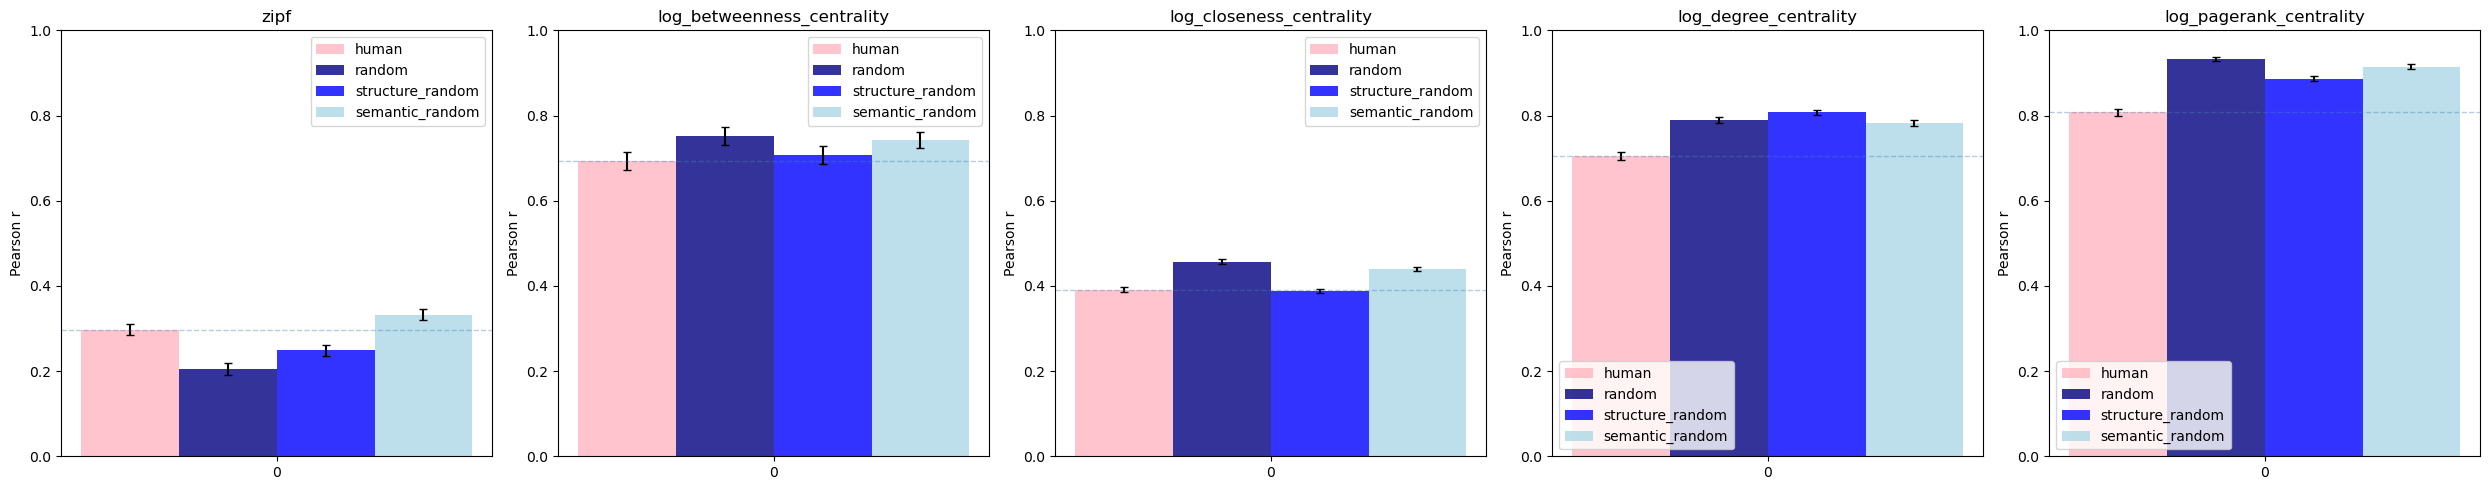

In [87]:
def compare_centralities_with_node_traversals(
    centrality_dict, node_dict, ax, centrality_str=""
):
    types = ["human", "random", "structure_random", "semantic_random"]
    counts, centralities = {t: [] for t in types}, []
    for node in node_dict["human"]:
        node_centrality = centrality_dict.get(node, 0)
        ccs = []
        for type in types:
            ccs.append(node_dict[type].get(node, 0))

        if (sum([t != 0 for t in ccs]) == 4) and (node_centrality != 0):
            for type, node_count in zip(types, ccs):
                counts[type].append(node_count)
            centralities.append(node_centrality)

    for random_type in types[1:]:
        r12, _ = pearsonr(centralities, np.log(counts[types[0]]))
        r13, _ = pearsonr(centralities, np.log(counts[random_type]))
        r23, _ = pearsonr(np.log(counts[types[0]]), np.log(counts[random_type]))

        print(
            f"Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with {centrality_str} than x3 = {random_type} is?)"
        )
        z, p = steiger_z_test(
            r12, r13, r23, n=len(counts[types[0]]), alternative="greater"
        )
        print(f"r12={r12:.3f}, r13={r13:.3f}, r23={r23:.3f}")
        print(f"Z={z:0.5f}, p={p:0.5f}")
        print()

    x = np.arange(1)  # len(centrality_measures))

    width = 0.2
    colors = {
        "human": "lightpink",
        "random": "navy",
        "structure_random": "blue",
        "semantic_random": "lightblue",
    }

    rs, ses, offsets = [], [], []
    for j, walker_type in enumerate(types):
        xl = np.log(counts[walker_type])
        _, _, r, _, se = stats.linregress(xl, centralities)
        rs.append(r)
        ses.append(se)

        offset = (j - len(types) / 2 + 0.5) * width
        ax.bar(
            offset,
            r,
            width,
            yerr=se,
            color=colors[walker_type],
            label=walker_type,
            alpha=0.8,
            capsize=3,
        )
    ax.axhline(rs[0], color="steelblue", linestyle="--", alpha=0.4, linewidth=1)

    ax.set_xticks(x)
    # ax.set_xticklabels([c.replace("log_","").replace("_centrality","").replace("_"," ")
    #                     for c in centrality_measures], rotation=20, ha='right')
    ax.set_ylabel("Pearson r")
    ax.set_ylim(0, 1)
    ax.set_title(centrality_str)
    ax.legend()

    # # Reference: vertical line at human r


fig, axes = plt.subplots(1, 5, figsize=(25, 5))

ax = axes[0]
compare_centralities_with_node_traversals(
    word_frequency_centrality,
    node_counts,
    ax=ax,
    centrality_str="zipf",
)

ax = axes[1]
log_betweenness_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in betweenness_centrality.items()
}
compare_centralities_with_node_traversals(
    log_betweenness_centrality,
    node_counts,
    ax=ax,
    centrality_str="log_betweenness_centrality",
)

ax = axes[2]
log_closeness_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in closeness_centrality.items()
}
compare_centralities_with_node_traversals(
    log_closeness_centrality,
    node_counts,
    ax=ax,
    centrality_str="log_closeness_centrality",
)

ax = axes[3]
log_degree_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in degree_centrality.items()
}
compare_centralities_with_node_traversals(
    log_degree_centrality,
    node_counts,
    ax=ax,
    centrality_str="log_degree_centrality",
)

ax = axes[4]
log_pagerank_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in pagerank_centrality.items()
}
compare_centralities_with_node_traversals(
    log_pagerank_centrality,
    node_counts,
    ax=ax,
    centrality_str="log_pagerank_centrality",
)
plt.tight_layout()
plt.show()

## 3. Idk make Flow Trees?

In [14]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
most_indegree_nodes = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)
least_indegree_nodes = find_k_most_x_nodes(
    node_indegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="indegree",
)
most_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
least_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="outdegree",
)

print()
print(
    "Most outdegree, most indegree overlap",
    len(set(most_indegree_nodes).intersection(set(most_outdegree_nodes))),
)
print(
    "Least outdegree, least indegree overlap",
    len(set(least_indegree_nodes).intersection(set(least_outdegree_nodes))),
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most indegree node is United_States with 1551; 50th most is Brazil with 261
Least indegree node is Education_in_the_United_States with 3; 50th least is Penguin with 26
Most outdegree node is United_States with 294; 50th most is NATO with 96
Least outdegree node is Animation with 3; 50th least is Pyramid with 17

Most outdegree, most indegree overlap 20
Least outdegree, least indegree overlap 16


In [15]:
len(degree_cache)

0

In [16]:
len(cosine_cache)

0

In [17]:
most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=6,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=15,
    plot_title_str=None,
)

Most indegree:


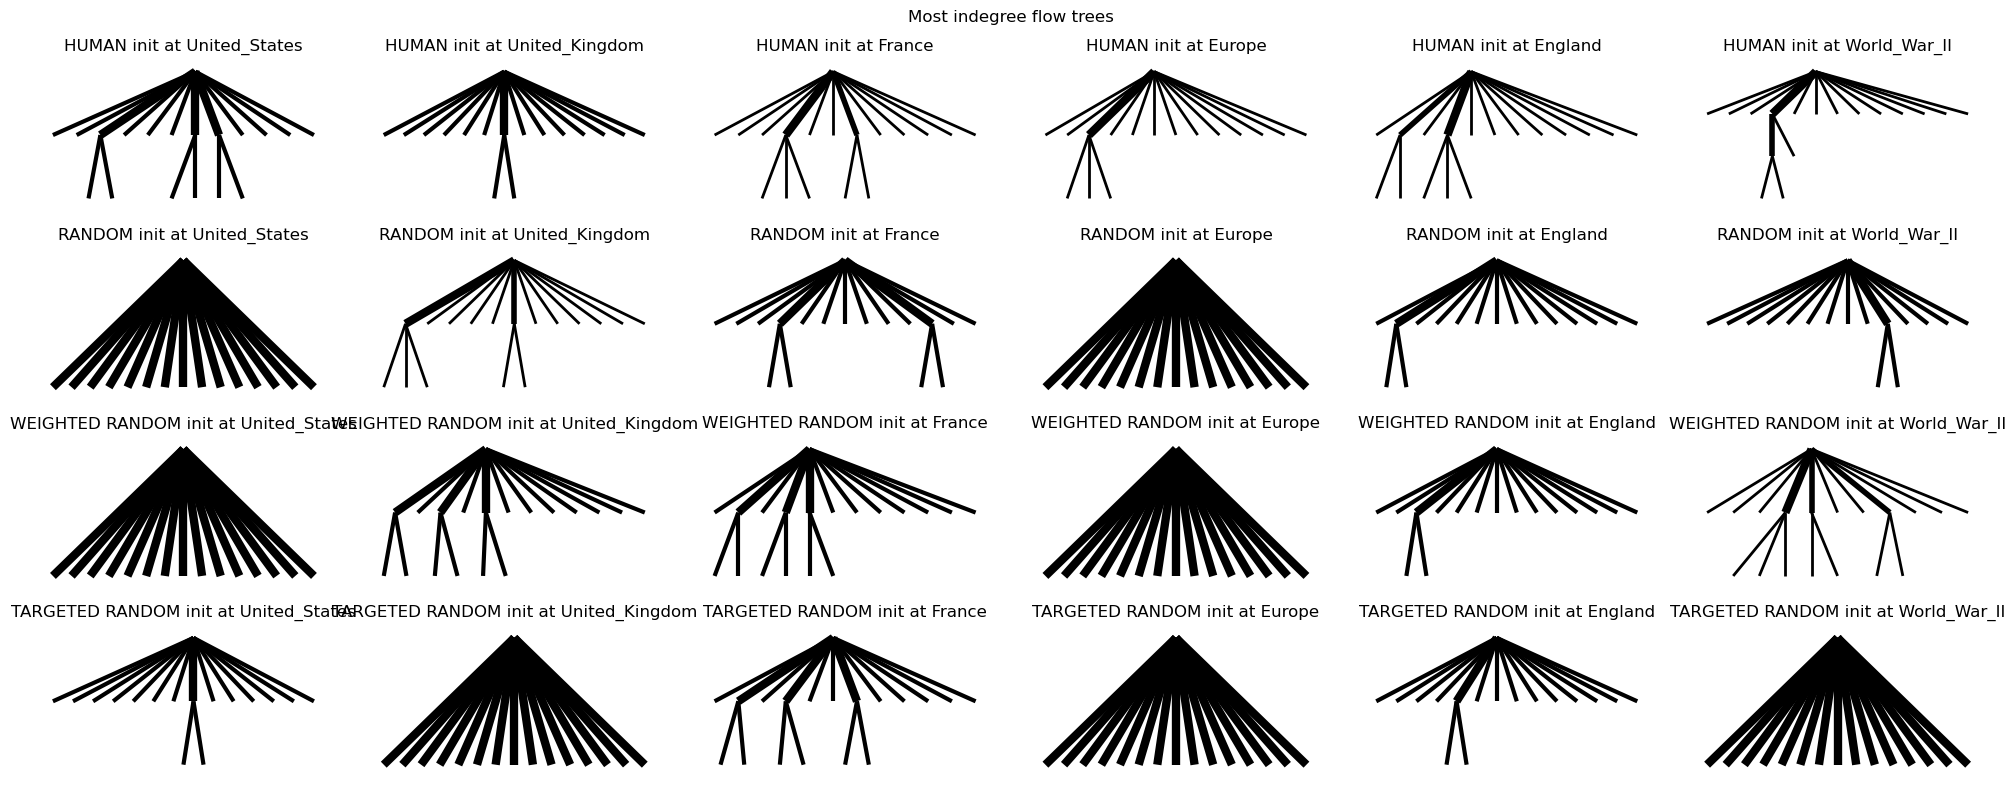

Least indegree:


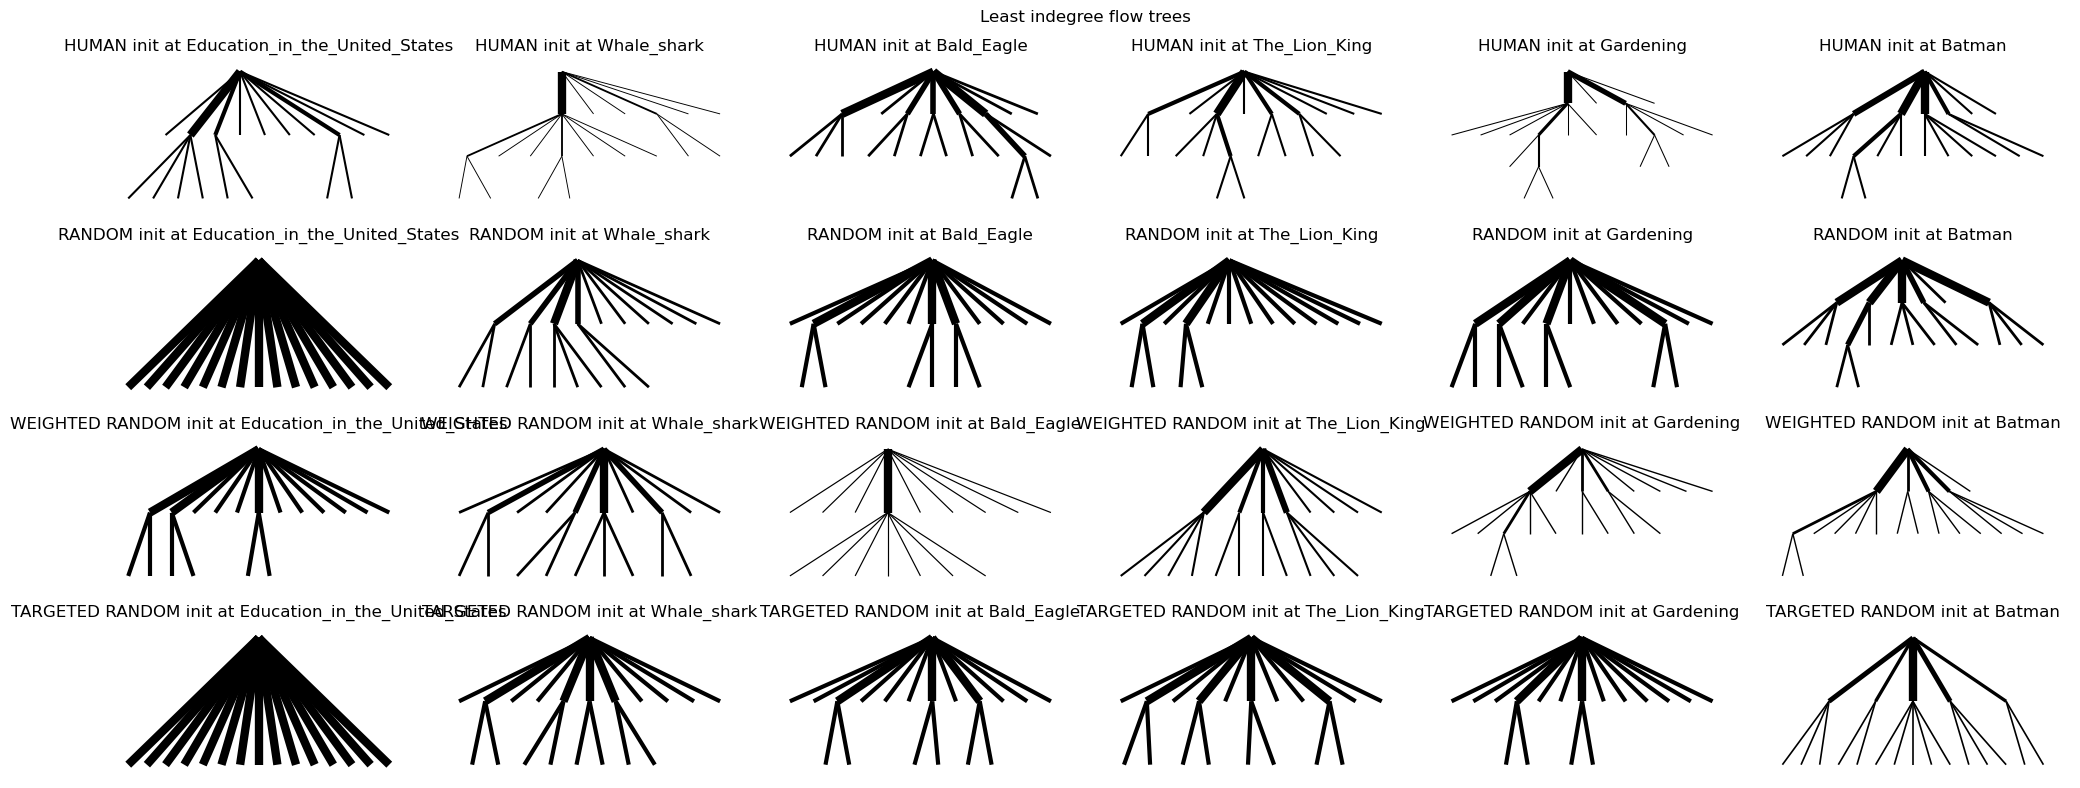

In [18]:
print("Most indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_indegree_nodes},
    title_str="Most indegree flow trees",
)
print("Least indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_indegree_nodes},
    title_str="Least indegree flow trees",
)

Most outdegree:


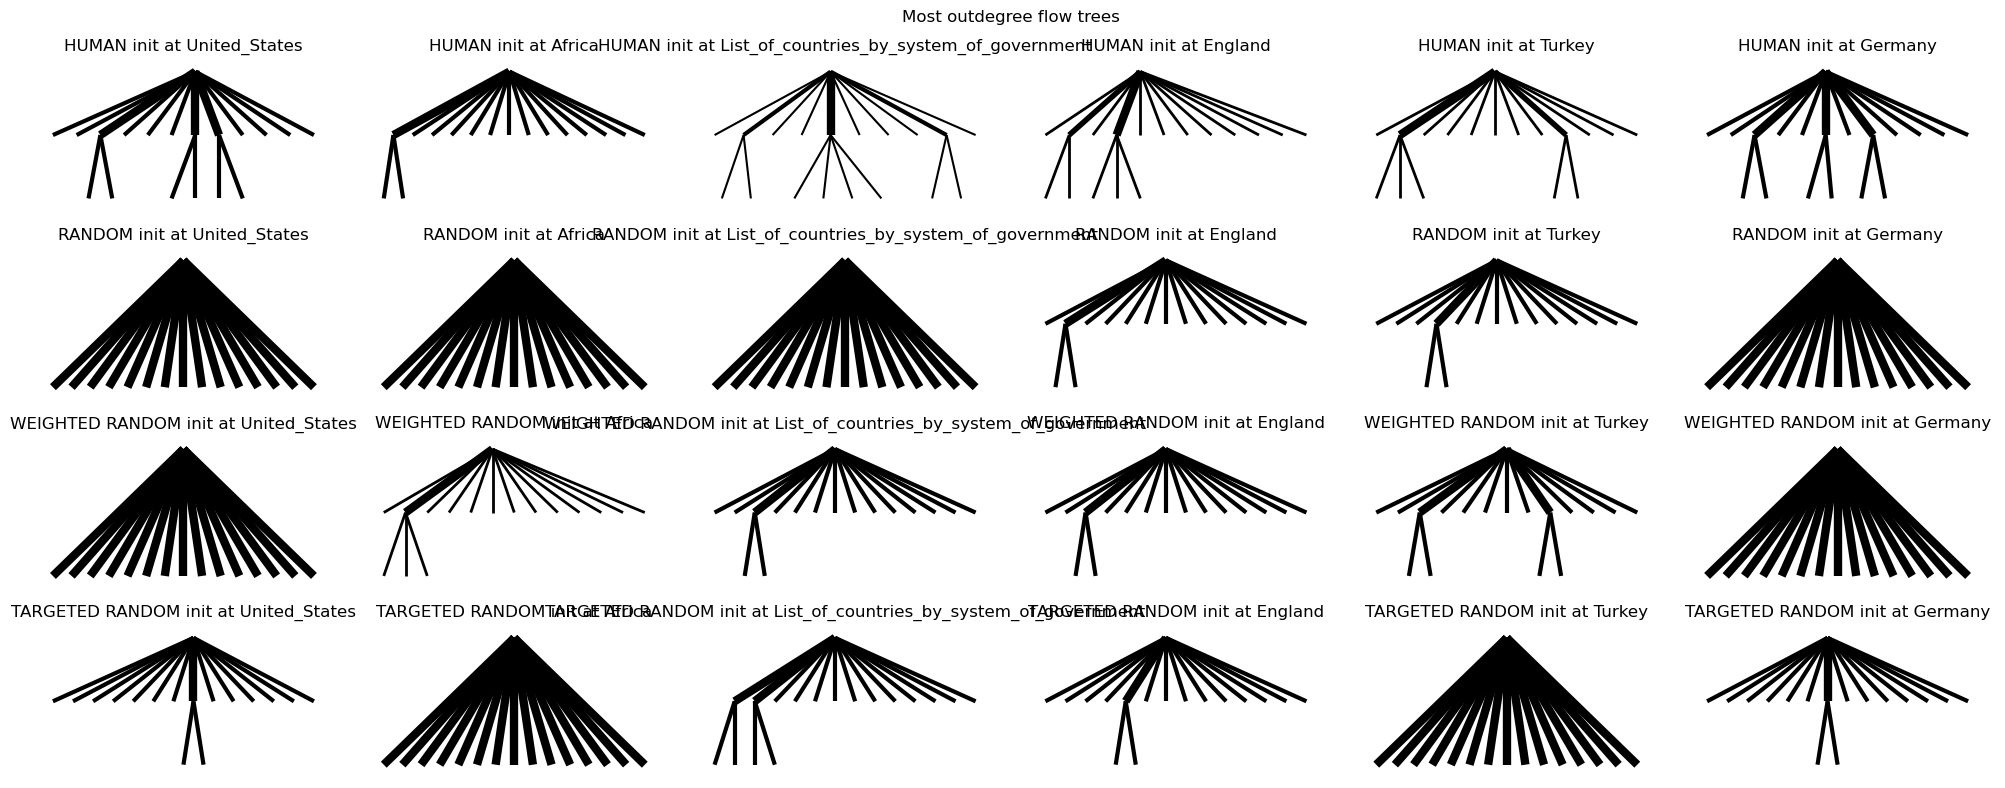

Least outdegree:


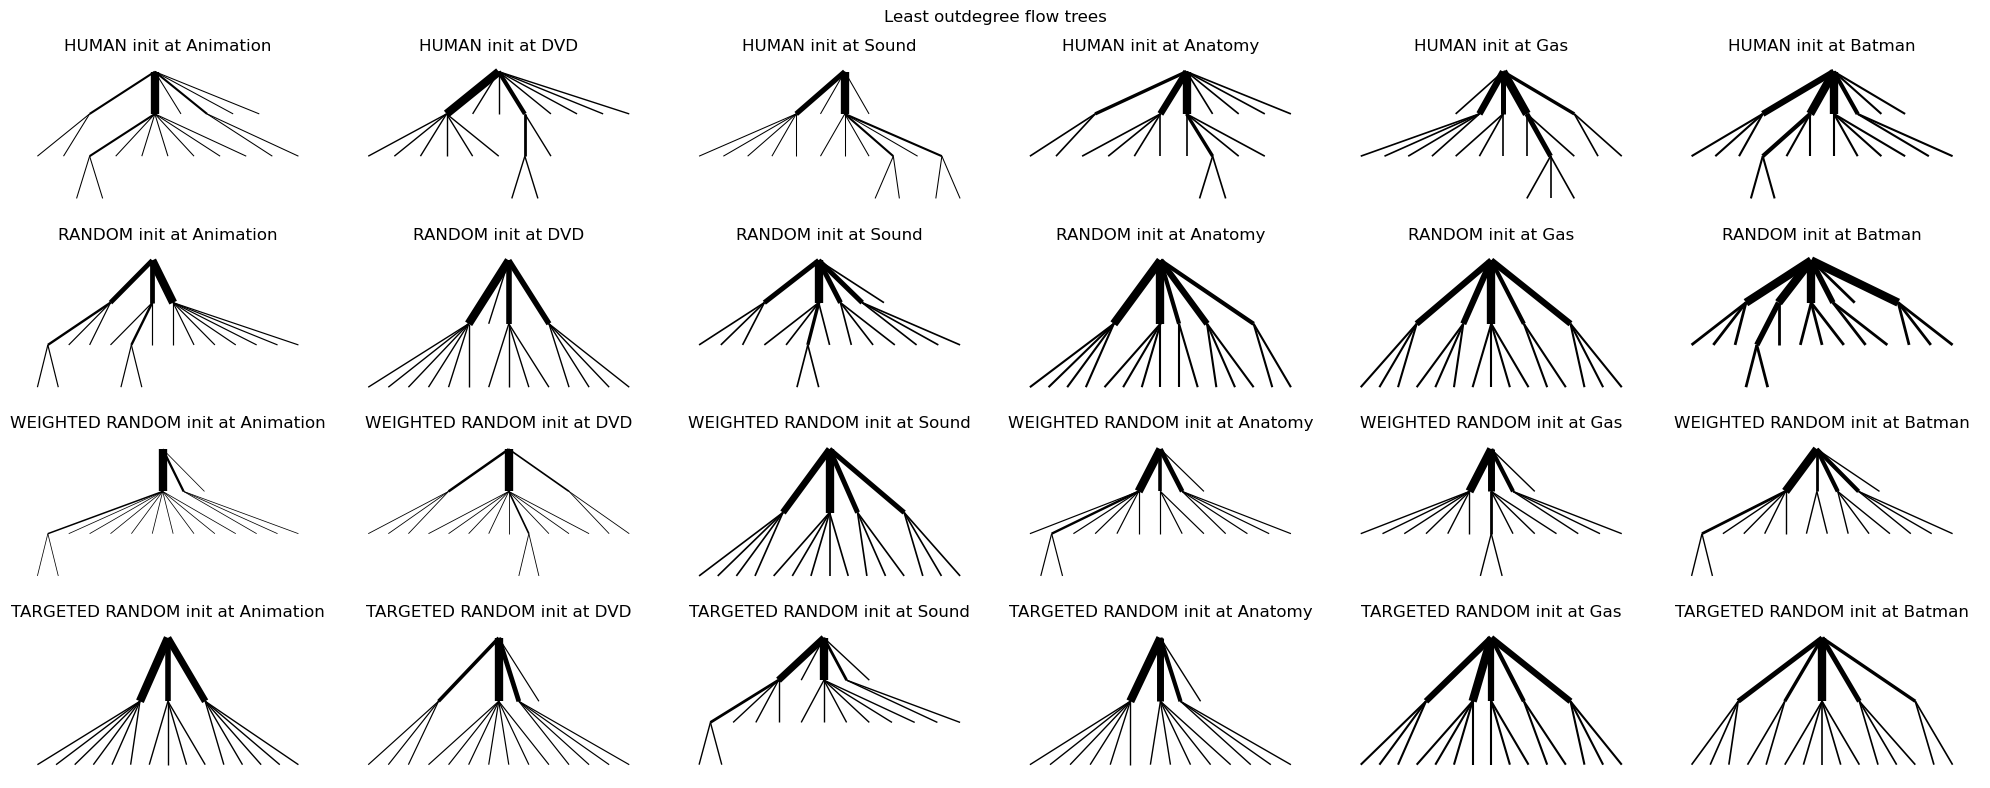

In [19]:
print("Most outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_outdegree_nodes},
    title_str="Most outdegree flow trees",
)
print("Least outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_outdegree_nodes},
    title_str="Least outdegree flow trees",
)

In [20]:
human_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_most_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human most outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human most outdegree,random most outdegree,18.128000,16.852000,1.303616,0.638096,250,250,14.449670,8.957575e-40,num_nodes,Comparing flow tree num_nodes between human mo...
1,human most outdegree,random most outdegree,14.960000,15.000000,0.046400,0.000000,250,250,-2.930223,3.542698e-03,num_leaves,Comparing flow tree num_leaves between human m...
2,human most outdegree,random most outdegree,2.056000,1.632000,0.188864,0.232576,250,250,10.306178,1.046245e-22,depth,Comparing flow tree depth between human most o...
3,human most outdegree,random most outdegree,3.764000,2.816000,0.532304,0.518144,250,250,14.595559,2.008096e-40,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,human most outdegree,random most outdegree,6.854829,10.454333,6.233939,12.803609,250,250,-13.017780,1.499921e-33,root_degree,Comparing flow tree root_degree between human ...


In [21]:
human_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    random_least_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="random least outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human least outdegree,random least outdegree,20.240000,20.680000,1.366400,1.153600,250,250,-4.373731,1.488294e-05,num_nodes,Comparing flow tree num_nodes between human le...
1,human least outdegree,random least outdegree,14.984000,15.000000,0.015744,0.000000,250,250,-2.012158,4.474123e-02,num_leaves,Comparing flow tree num_leaves between human l...
2,human least outdegree,random least outdegree,2.712000,2.292000,0.309056,0.206736,250,250,9.228087,7.858862e-19,depth,Comparing flow tree depth between human least ...
3,human least outdegree,random least outdegree,4.868000,4.340000,0.562576,0.336400,250,250,8.787383,2.486196e-17,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,human least outdegree,random least outdegree,4.613989,4.385005,0.459141,0.299421,250,250,4.148675,3.932224e-05,root_degree,Comparing flow tree root_degree between human ...


In [22]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    human_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="human most outdegree",
)
results_df[
    (results_df.group1_mean > results_df.group2_mean) & (results_df.p_value < 0.05)
][["group2_mean", "group1_mean", "metric"]]

,group2_mean,group1_mean,metric
0,18.128,20.240,num_nodes
2,2.056,2.712,depth
3,3.764,4.868,diameteravg_branching_factor


In [23]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    random_least_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="random least outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,random least outdegree,random most outdegree,20.680000,16.852000,1.153600,0.638096,250,250,45.127309,4.389666e-178,num_nodes,Comparing flow tree num_nodes between random l...
1,random least outdegree,random most outdegree,15.000000,15.000000,0.000000,0.000000,250,250,NaN,NaN,num_leaves,Comparing flow tree num_leaves between random ...
2,random least outdegree,random most outdegree,2.292000,1.632000,0.206736,0.232576,250,250,15.712926,1.776016e-45,depth,Comparing flow tree depth between random least...
3,random least outdegree,random most outdegree,4.340000,2.816000,0.336400,0.518144,250,250,26.014616,7.327759e-95,diameteravg_branching_factor,Comparing flow tree diameteravg_branching_fact...
4,random least outdegree,random most outdegree,4.385005,10.454333,0.299421,12.803609,250,250,-26.457844,5.520106e-97,root_degree,Comparing flow tree root_degree between random...


### Landmark testing

In [24]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
if "Wikipedia_Text_of_the_GNU_Free_Documentation_License" in most_common_nodes:
    most_common_nodes.remove("Wikipedia_Text_of_the_GNU_Free_Documentation_License")

outdegree_landmarks = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
player_landmarks = find_k_most_x_nodes(
    node_counts, k=small_k, restrict_to=most_common_nodes, verbose_str="common"
)
semantic_landmarks = find_k_most_x_nodes(
    node_zipf_frequencies, k=small_k, restrict_to=most_common_nodes, verbose_str="zipf"
)


print()
print(
    "Most outdegree, most player overlap",
    len(set(outdegree_landmarks).intersection(set(player_landmarks))),
)
print(
    "Most player, most zipf overlap",
    len(set(player_landmarks).intersection(set(semantic_landmarks))),
)
print(
    "Most outdegree, most zipf overlap",
    len(set(outdegree_landmarks).intersection(set(semantic_landmarks))),
)

print(
    set(outdegree_landmarks)
    .intersection(set(player_landmarks))
    .intersection(set(semantic_landmarks))
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most outdegree node is United_States with 294; 50th most is NATO with 96
Most common node is United_States with 12660; 50th most is Water with 1093
Most zipf node is Time with 6.29; 50th most is Black_Sea with 5.26

Most outdegree, most player overlap 20
Most player, most zipf overlap 8
Most outdegree, most zipf overlap 9
{'Water', 'South_America', 'United_States', 'Human', 'London', 'World_War_II'}


In [25]:
indegree_landmarks = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)

Most indegree node is United_States with 1551; 50th most is Brazil with 261


In [26]:
most_common_nodes = set(most_common_nodes)
outdegree_landmarks = set(outdegree_landmarks)
player_landmarks = set(player_landmarks)
semantic_landmarks = set(semantic_landmarks)
indegree_landmarks = set(indegree_landmarks)

In [27]:
min_path_length = 5
traj_per_tree = 15

most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=min_path_length,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=traj_per_tree,
    plot_title_str=None,
)

rev_wikiG = wikiG.reverse()
rev_traj_dict = make_rev_traj_dict(
    most_common_nodes, trajs_df, min_path_length=min_path_length
)
most_common_rev_flow_tree_dict = sample_flow_trees_from_traj_dict(
    rev_traj_dict, rev_wikiG, k_fold=5, traj_per_tree=traj_per_tree
)

### ft-landmarks

In [28]:
node_ft_scores = {}
for node in most_common_nodes:
    trees = most_common_flow_tree_dict.get(node, {}).get("human", [])
    if not trees:
        continue
    depths = [tree_depth(G, 0) for G in trees]
    bfs = [branching_factor(G) for G in trees]
    ft_score = np.mean(bfs) / max(np.mean(depths), 0.5)
    node_ft_scores[node] = ft_score

ft_landmarks = find_k_most_x_nodes(
    node_ft_scores, k=small_k, restrict_to=most_common_nodes, verbose_str="ft_score"
)
ft_landmarks = set(ft_landmarks)
ft_landmarks

Most ft_score node is Spain with 6.666666666666666; 50th most is Galileo_Galilei with 3.275


{'21st_century',
 'Alchemy',
 'Ancient_Greece',
 'Argentina',
 'Austria',
 'Bird',
 'British_monarchy',
 'Byzantine_Empire',
 'Capital',
 'China',
 'Electromagnetic_radiation',
 'Elizabeth_II_of_the_United_Kingdom',
 'Energy',
 'England',
 'Ethiopia',
 'Finland',
 'France',
 'Galileo_Galilei',
 'German_language',
 'Germany',
 'Gold',
 'Greenland',
 'Holy_Roman_Empire',
 'Human',
 'India',
 'Israel',
 'Light',
 'London',
 'Mammal',
 'Mass_media',
 'Milk',
 'Netherlands',
 'Ottoman_Empire',
 'Pacific_Ocean',
 'People%27s_Republic_of_China',
 'Periodic_table',
 'Poland',
 'Pollution',
 'Portugal',
 'Russia',
 'Saudi_Arabia',
 'Spain',
 'Star',
 'Steel',
 'Tourism',
 'Turkey',
 'United_Kingdom',
 'United_States',
 'World_War_I',
 'World_War_II'}

In [29]:
# all_subjs = test_df["Subject"].unique()
# subjs_group1 = np.random.choice(all_subjs, len(all_subjs) // 2)
# subjs_group2 = set(all_subjs) - set(subjs_group1)

# better_direction_accs = []
# worse_direction_accs = []
# for i in range(len(OBJECTS)):
#     for j in range(i + 1, len(OBJECTS)):
#         start_node, end_node = OBJECTS[i], OBJECTS[j]

#         accs1_df = test_df[
#             (test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)
#         ][["accuracy", "Subject"]]
#         accs2_df = test_df[
#             (test_df["StartAt"] == end_node) & (test_df["EndAt"] == start_node)
#         ][["accuracy", "Subject"]]

#         intersection_df = pd.merge(accs1_df, accs2_df, how="inner", on=["Subject"])

#         dir_select_df = intersection_df[intersection_df["Subject"].isin(subjs_group1)]
#         acc1 = np.mean(dir_select_df["accuracy_x"].astype(float))
#         acc2 = np.mean(dir_select_df["accuracy_y"].astype(float))
#         dir_1_better = acc1 > acc2

#         # Cross validation
#         cross_val_df = intersection_df[intersection_df["Subject"].isin(subjs_group2)]
#         accs1 = cross_val_df["accuracy_x"].astype(float)
#         accs2 = cross_val_df["accuracy_y"].astype(float)

#         acc1 = np.mean(accs1)
#         acc2 = np.mean(accs2)

#         if dir_1_better:  # end_node not in ("W", "N", "O") :
#             # continue
#             # better_direction_accs.extend(accs1)
#             # worse_direction_accs.extend(accs2)
#             better_direction_accs.append(acc1)
#             worse_direction_accs.append(acc2)
#         else:
#             # better_direction_accs.extend(accs2)
#             # worse_direction_accs.extend(accs1)
#             better_direction_accs.append(acc2)
#             worse_direction_accs.append(acc1)

# # Perform Mann-Whitney U test since we can't assume normal distribution
# # statistic, p_value = stats.mannwhitneyu(better_direction_accs, worse_direction_accs, alternative="less")
# statistic, p_value = stats.ttest_rel(better_direction_accs, worse_direction_accs)

# print(np.mean(better_direction_accs))
# print(np.mean(worse_direction_accs))
# print(f"{statistic} p={p_value}", len(better_direction_accs))

### Landmark vs. Non-Landmark Flow Tree Examples

In [30]:
def plot_n_trees(flow_trees):
    fig, axes = plt.subplots(2, len(flow_trees) // 2, figsize=(10, 5))
    axes = axes.flatten()
    for i, ft in enumerate(flow_trees):
        plot_flow_tree(ft, f"FT", axes[i], just_edges=True, no_title=False)
    plt.tight_layout()
    plt.show()

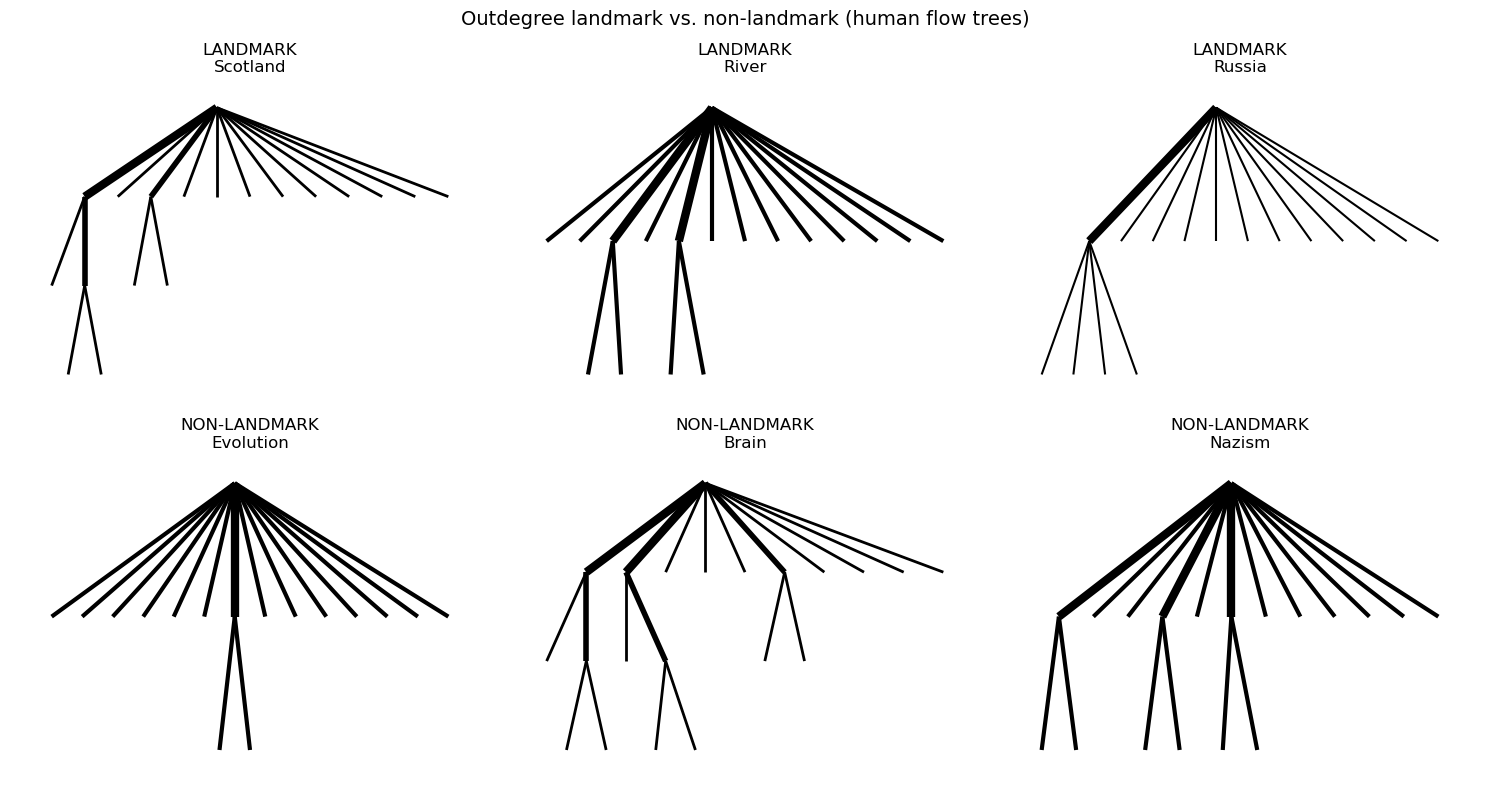

In [31]:
def plot_landmark_vs_nonlandmark(
    flow_tree_dict,
    landmark_nodes,
    all_nodes,
    landmark_type_str,
    n_examples=3,
    person="human",
):
    non_landmark_nodes = [n for n in all_nodes if n not in landmark_nodes]

    landmark_sample = random.sample(
        sorted(landmark_nodes), min(n_examples, len(landmark_nodes))
    )
    non_landmark_sample = random.sample(
        non_landmark_nodes, min(n_examples, len(non_landmark_nodes))
    )

    fig, axes = plt.subplots(2, n_examples, figsize=(5 * n_examples, 8))
    fig.suptitle(
        f"{landmark_type_str} landmark vs. non-landmark (human flow trees)", fontsize=14
    )

    for j, node in enumerate(landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"LANDMARK\n{node}", axes[0][j], just_edges=True, no_title=False
        )

    for j, node in enumerate(non_landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"NON-LANDMARK\n{node}", axes[1][j], just_edges=True, no_title=False
        )

    axes[0][0].set_ylabel("Landmark", fontsize=12)
    axes[1][0].set_ylabel("Non-Landmark", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_landmark_vs_nonlandmark(
    most_common_flow_tree_dict, outdegree_landmarks, most_common_nodes, "Outdegree"
)

# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, player_landmarks, most_common_nodes, "Player")
# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, semantic_landmarks, most_common_nodes, "Semantic")


In [42]:
def compute_asymmetry(forward_trees, reverse_trees, metric="bf"):
    """
    AS = mean(reverse metric) - mean(forward metric)
    metric: "diameter" or "bf"
    """
    forward_vals = []
    reverse_vals = []

    for tree in forward_trees:
        if metric == "diameter":
            forward_vals.append(nx.diameter(tree))
        elif metric == "bf":
            bfs = [
                len(list(tree.neighbors(n)))
                for n in tree.nodes()
                if len(list(tree.neighbors(n))) > 0
            ]
            forward_vals.append(np.mean(bfs) if bfs else 0)

    for tree in reverse_trees:
        if metric == "diameter":
            reverse_vals.append(nx.diameter(tree))
        elif metric == "bf":
            bfs = [
                len(list(tree.neighbors(n)))
                for n in tree.nodes()
                if len(list(tree.neighbors(n))) > 0
            ]
            reverse_vals.append(np.mean(bfs) if bfs else 0)

    return np.mean(reverse_vals) - np.mean(forward_vals)

    # forward_bfs = []
    # reverse_bfs = []

    # # Branching Factor
    # for tree in forward_trees:
    #     branching_factors = [
    #         len(list(tree.neighbors(node)))
    #         for node in tree.nodes()
    #         if tree.degree(node) != 1
    #     ]
    #     depth = tree_depth(tree, 0)
    #     ft_score = np.mean(branching_factors) / max(depth, 0.5)
    #     # forward_bfs.append(branching_factors[0])
    #     diam = nx.diameter(tree)
    #     forward_bfs.append(diam)

    # for tree in reverse_trees:
    #     branching_factors = [
    #         len(list(tree.neighbors(node)))
    #         for node in tree.nodes()
    #         if tree.degree(node) != 1
    #     ]
    #     depth = tree_depth(tree, 0)
    #     ft_score = np.mean(branching_factors) / max(depth, 0.5)
    #     # reverse_bfs.append(np.mean(branching_factors))
    #     diam = nx.diameter(tree)
    #     reverse_bfs.append(diam)  # branching_factors[0])

    # return np.mean(reverse_bfs) - np.mean(forward_bfs)


## Formal asymmetry test
landmark_lists = {
    "outdegree": outdegree_landmarks,
    "indegree": indegree_landmarks,
    "player": player_landmarks,
    "semantic": semantic_landmarks,
    "ft": ft_landmarks,
}

# Correct comparison: human beacons vs random walker beacons (same nodes)
for metric in ["bf", "diameter"]:
    print("METRIC", metric)

    for landmark_type, landmark_list in landmark_lists.items():
        human_asymms = []
        random_asymms = []

        for node in most_common_flow_tree_dict:
            if node not in landmark_list:
                continue
            fwd_h = most_common_flow_tree_dict[node]["human"]
            rev_h = most_common_rev_flow_tree_dict[node]["human"]
            fwd_r = most_common_flow_tree_dict[node]["random"]
            rev_r = most_common_rev_flow_tree_dict[node]["random"]

            human_asymms.append(compute_asymmetry(fwd_h, rev_h, metric=metric))
            random_asymms.append(compute_asymmetry(fwd_r, rev_r, metric=metric))

        t, p = stats.ttest_ind(human_asymms, random_asymms)
        print(
            f"{landmark_type}: human M={np.mean(human_asymms):.3f}, "
            f"random M={np.mean(random_asymms):.3f}, t={t:.3f}, p={p:.4f}"
        )

# for landmark_type, landmark_list in landmark_lists.items():
#     asymms_dict = {"human": [], "random": []}
#     for person in ["human"]:  # , "random"]:
#         asymms_l = []
#         asymms_nl = []
#         for node in most_common_flow_tree_dict:
#             forward_trees = most_common_flow_tree_dict[node][person]
#             reverse_trees = most_common_rev_flow_tree_dict[node][person]

#             asymmetry = compute_asymmetry(forward_trees, reverse_trees)
#             # asymmetry = node_indegrees[node]# / node_outdegrees[node]
#             if node in landmark_list:
#                 asymms_l.append(asymmetry)
#             else:
#                 asymms_nl.append(asymmetry)
#         # asymms_dict[person].extend(asymms)
#         asymms_dict["human"].extend(asymms_l)
#         asymms_dict["random"].extend(asymms_nl)

#         print("human", np.mean(asymms_l), np.std(asymms_l))
#         print("random", np.mean(asymms_nl), np.std(asymms_nl))
#     # print(len(asymms_dict["human"]))
#     t_stat, p_val = stats.ttest_ind(asymms_dict["human"], asymms_dict["random"])
#     print(landmark_type, t_stat, p_val)
#     print()

METRIC bf
outdegree: human M=-0.005, random M=0.002, t=-5.599, p=0.0000
indegree: human M=-0.006, random M=-0.000, t=-4.477, p=0.0000
player: human M=-0.006, random M=-0.001, t=-3.935, p=0.0002
semantic: human M=-0.008, random M=-0.004, t=-3.098, p=0.0025
ft: human M=-0.002, random M=0.000, t=-2.020, p=0.0461
METRIC diameter
outdegree: human M=-0.464, random M=0.060, t=-4.383, p=0.0000
indegree: human M=-0.504, random M=-0.104, t=-3.370, p=0.0011
player: human M=-0.592, random M=-0.160, t=-3.348, p=0.0012
semantic: human M=-0.700, random M=-0.356, t=-2.452, p=0.0160
ft: human M=-0.128, random M=-0.088, t=-0.330, p=0.7421


outdegree human
                         metric  group1_mean  group2_mean direction  \
0                     num_nodes    18.284000    19.188889      less   
2                         depth     2.152000     2.336000      less   
3  diameteravg_branching_factor     3.860000     4.288000      less   
4                   root_degree     6.567762     5.367502      more   

        p_value  
0  3.117057e-24  
2  9.891757e-08  
3  1.138673e-19  
4  8.311109e-34  
player human
        metric  group1_mean  group2_mean direction   p_value
0    num_nodes    18.828000    19.128444      less  0.000834
4  root_degree     5.916948     5.439815      more  0.000002
(250, 6)
(2500,)
semantic human
                         metric  group1_mean  group2_mean direction   p_value
0                     num_nodes    19.176000    19.089778      more  0.338117
1                    num_leaves    14.940000    14.920444      more  0.439052
2                         depth     2.336000     2.315556      more  0.55490

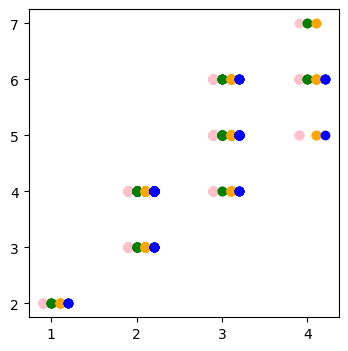

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for person in ["human", "random"]:
    outdegree_landmark_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_flowtrees,
        outdegree_non_landmark_flowtrees,
        normalise=False,
        group1_name="outdegree landmark",
        group2_name="outdegree not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    player_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_flowtrees,
        player_non_landmark_flowtrees,
        normalise=False,
        group1_name="player landmark",
        group2_name="player not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print(group1_features.shape)
    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "diameter",
    ]
    depths = np.concatenate((group1_features[:, 2], group2_features[:, 2]))
    avg_branching_factors = np.concatenate(
        (group1_features[:, 3], group2_features[:, 3])
    )

    ax.scatter(group2_features[:, 2] - 0.1, group2_features[:, 3], c="pink", alpha=0.5)
    ax.scatter(group1_features[:, 2], group1_features[:, 3], c="green")
    print(depths.shape)

    semantic_landmark_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_flowtrees,
        semantic_non_landmark_flowtrees,
        normalise=False,
        group1_name="semantic landmark",
        group2_name="semantic not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("semantic", person)
    print(
        results_df[results_df.p_value < 1][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    ax.scatter(
        group2_features[:, 2] + 0.1, group2_features[:, 3], c="orange", alpha=0.5
    )
    ax.scatter(group1_features[:, 2] + 0.2, group1_features[:, 3], c="blue")
    break

    print()
    print("----------------")
    print()
plt.show()

In [34]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),  # ← origin, not the data mean
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        **kwargs,
    )
    # no set_angle() — handled by the transform below

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    trans = (
        transforms.Affine2D()
        .rotate_deg(45)  # ← always 45° for the Pearson formulation
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)  # ← translation happens exactly once
    )
    ellipse.set_transform(trans + ax.transData)
    return ax.add_patch(ellipse)

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_2092/3900593699.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])


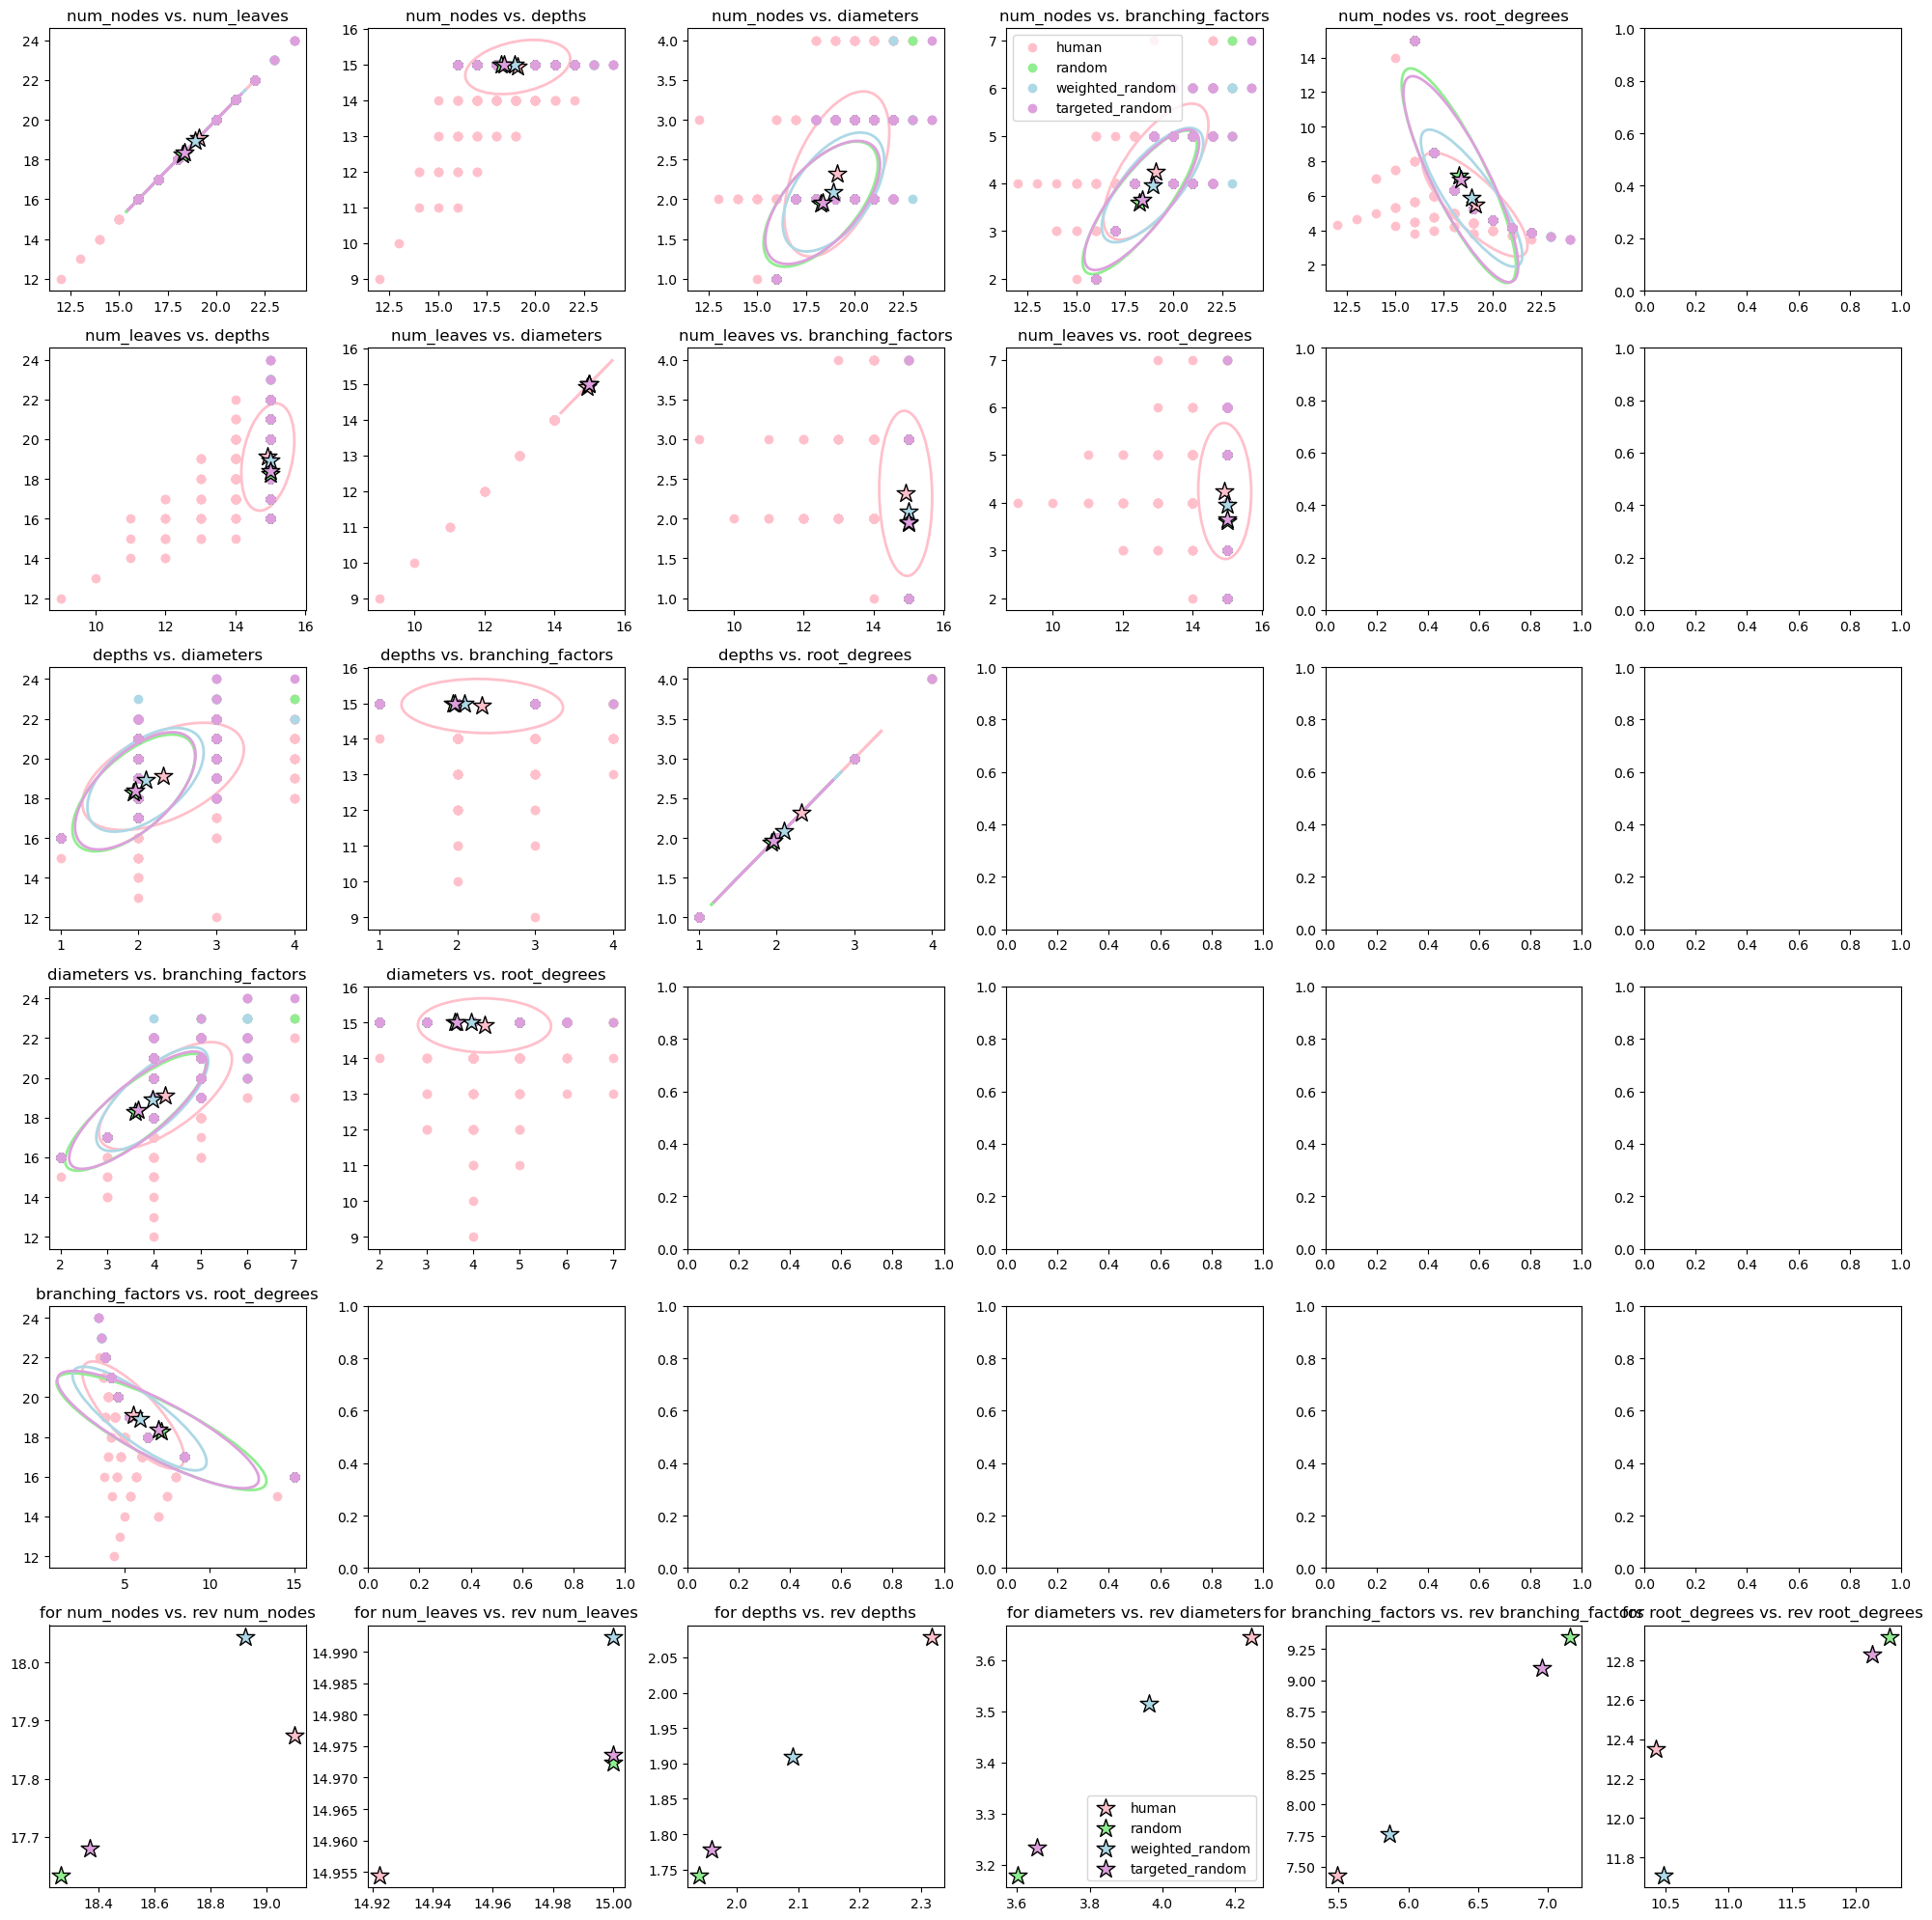

In [ ]:
# Plot by all sorts of things!!
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
feature_names = [
    "num_nodes",
    "num_leaves",
    "depths",
    "diameters",
    "branching_factors",
    "root_degrees",
]
fig, axes = plt.subplots(6, 6, figsize=(20, 20))

for i, group in enumerate(["human", "random", "weighted_random", "targeted_random"]):
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    rev_features = np.array([extract_tree_features(G, 0) for G in rev_trees])
    # print(rev_features)
    for_trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]
    for_features = np.array([extract_tree_features(G, 0) for G in for_trees])

    # plot_n_trees(rev_trees[:10])
    # plot_n_trees(for_trees[:10])

    for ii, feats in enumerate(
        [
            for_features,
        ]
    ):
        for j, feat1_name in enumerate(feature_names):
            for k, feat2_name in enumerate(feature_names[j + 1 :]):
                axes[j, k].scatter(
                    feats[:, j], feats[:, k], c=colors[i + 4 * ii], label=group
                )
                axes[j, k].scatter(
                    feats[:, j].mean(),
                    feats[:, k].mean(),
                    c=colors[i + 4 * ii],
                    alpha=1,
                    s=200,
                    marker="*",
                    edgecolors="black",
                    zorder=10,
                )
                confidence_ellipse(
                    feats[:, j],
                    feats[:, k],
                    axes[j, k],
                    n_std=2.0,
                    edgecolor=colors[i + 4 * ii],
                    facecolor="none",
                    linewidth=2,
                )
                axes[j, k].set_title(f"{feat1_name} vs. {feat2_name}")

    for j, feat_name in enumerate(feature_names):
        # axes[j, k].scatter(feats[j], feats[k], c=colors[i + 4 * ii], label=group)
        axes[-1, j].scatter(
            for_features[:, j].mean(),
            rev_features[:, j].mean(),
            c=colors[i + 4 * ii],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            zorder=10,
            label=group,
        )
        # confidence_ellipse(
        #     feats[j],
        #     feats[k],
        #     axes[j, k],
        #     n_std=2.0,
        #     edgecolor=colors[i + 4 * ii],
        #     facecolor="none",
        #     linewidth=2,
        # )
        axes[-1, j].set_title(f"for {feat_name} vs. rev {feat_name}")

axes[0, 3].legend()
axes[-1, 3].legend()
plt.tight_layout()
plt.show()


In [ ]:
## feature pca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_dict = {}
labels_dict = {}
trees_dict = {}

for group in ["human", "random", "weighted_random", "targeted_random"]:
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]

    rev_features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )
    rev_labels = np.array(
        [
            "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    labels = np.array(
        [
            "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )

    # features_dict[group] = [f[:-1] for f in features if True]#f[0] in [18]]
    features_dict["rev-" + group] = [
        f[:-1] for f in rev_features if True
    ]  # f[0] in [18]]
    # labels_dict[group] = labels
    labels_dict["rev-" + group] = rev_labels
    # trees_dict[group] = trees
    trees_dict["rev-" + group] = rev_trees

all_features = np.concatenate(list(features_dict.values()))

scaler = StandardScaler()
all_scaled = scaler.fit_transform(all_features)

pca = PCA(n_components=3)  # 0.95

X_pca = pca.fit_transform(all_scaled)

print("Original shape:", all_scaled.shape)
print("Transformed shape:", X_pca.shape)
print("Number of components chosen:", pca.n_components_)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (10000, 5)
Transformed shape: (10000, 3)
Number of components chosen: 3
Explained variance ratio: [0.71438425 0.20424729 0.04835209]
Cumulative explained variance: 0.9669836380725092


[[ 9.12249673e-01  1.63385226e-01  3.45896947e-01]
 [-5.77907315e-02  9.95165551e-01 -7.73831102e-02]
 [ 9.25129421e-01 -5.98382600e-02 -3.40777551e-01]
 [ 9.79379926e-01 -1.63269500e-02 -2.12776347e-04]
 [-9.60046761e-01  2.10285090e-02  4.73380701e-03]]
rev-human 2500
rev-random 2500
rev-weighted_random 2500
rev-targeted_random 2500


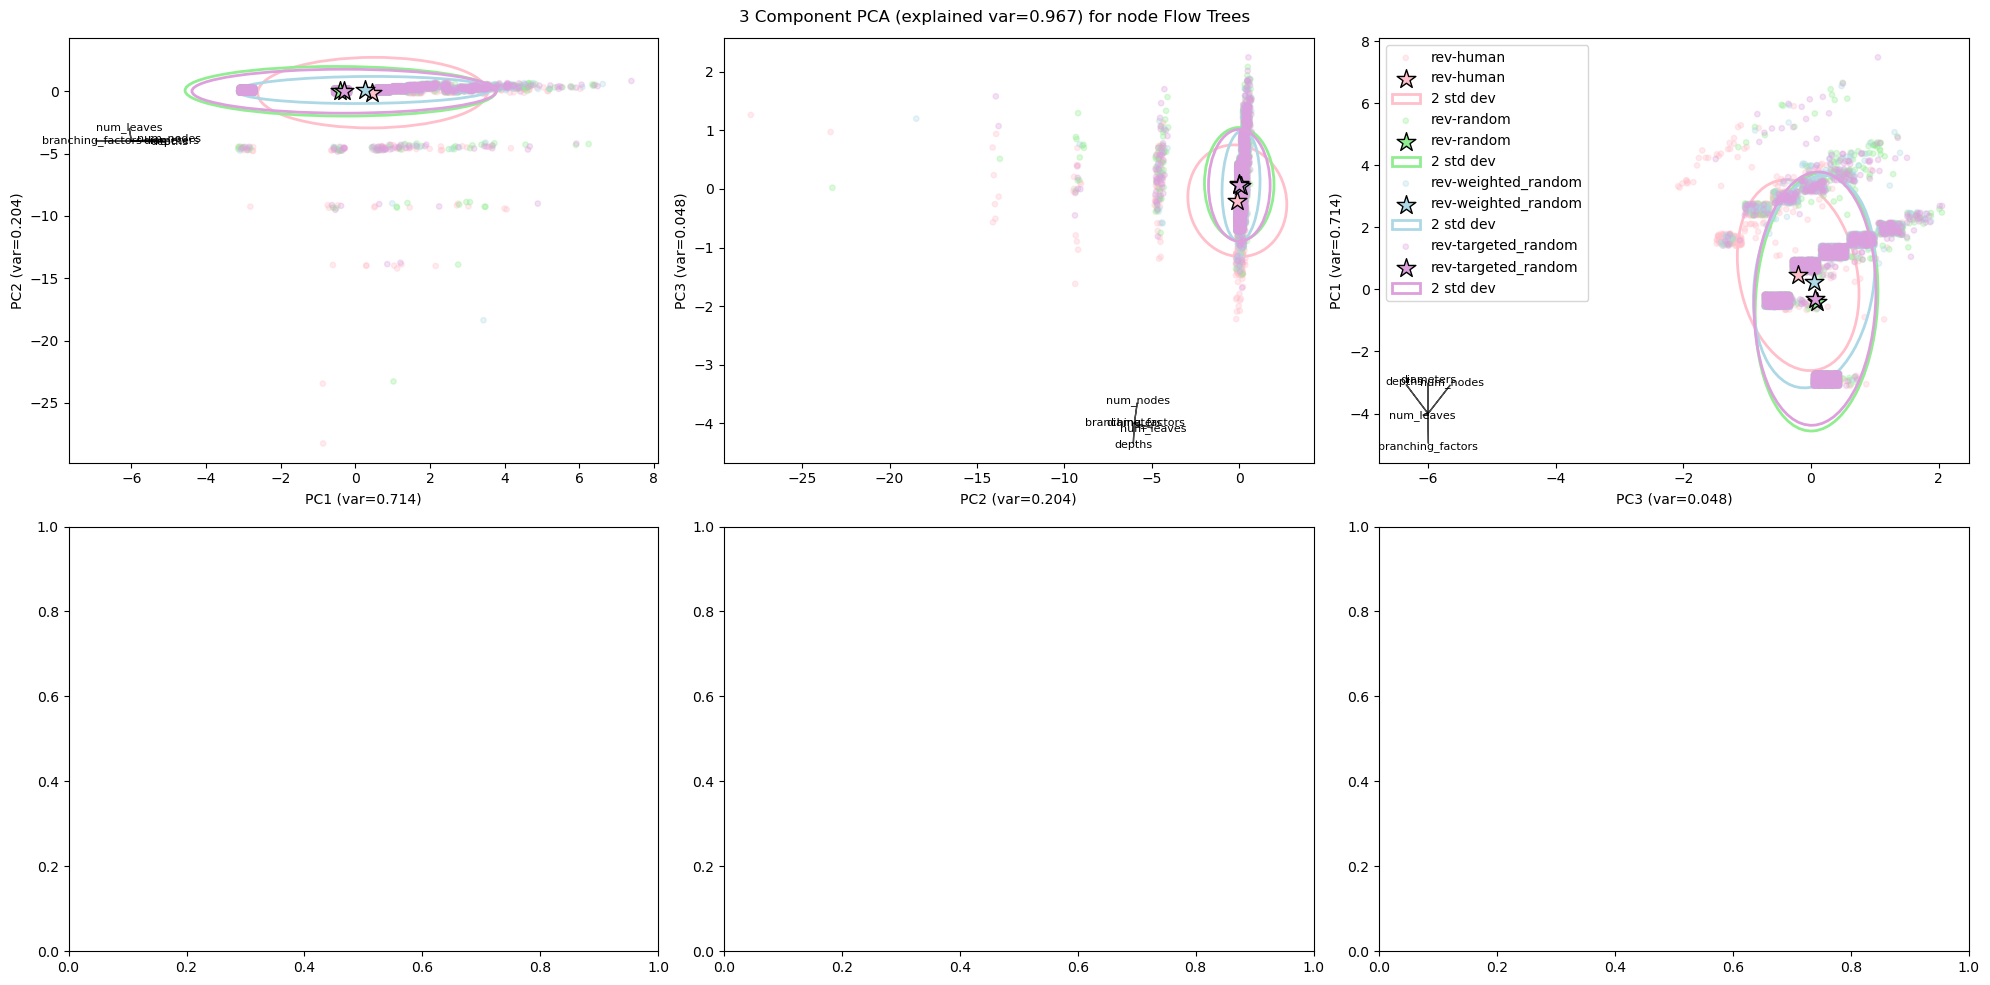

num_nodes
mean\_{human}=17.8736, mean\_{random}=17.6332
var\_{human}=1.5160230399999997, var\_{random}=3.1026577600000005
t=5.591889964883693, p=2.3654871488387565e-08
levene=174.5104264058936, p=3.452271135786087e-39
num_leaves
mean\_{human}=14.9544, mean\_{random}=14.9724
var\_{human}=0.09072064, var\_{random}=0.04523824
t=-2.4403484592683182, p=0.014707603806048505
levene=5.9553006026528035, p=0.01470760380615225
depths
mean\_{human}=2.0788, mean\_{random}=1.7416
var\_{human}=0.29339056, var\_{random}=0.37082944
t=20.683056574000936, p=2.9662406459973226e-91
levene=119.96666583114848, p=1.3221804871467386e-27
diameters
mean\_{human}=3.6456, mean\_{random}=3.1784
var\_{human}=0.7456006399999999, var\_{random}=1.0769734400000002
t=17.29989102205862, p=3.608709178886293e-65
levene=160.347199633701, p=3.400134694084416e-36
branching_factors
mean\_{human}=7.42812761904762, mean\_{random}=9.34807634920635
var\_{human}=8.0864380105161, var\_{random}=18.563337973099998
t=-18.59199433008368,

0.7733726985454173

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
print(loadings)
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

ccs = ["red", "purple", "blue", "green", "yellow", "orange", "black", "grey"]
for j, group in enumerate(features_dict):
    features = features_dict[group]
    print(group, len(features))
    labels = labels_dict[group]

    scaled_features = scaler.transform(features)
    featuers_pca = pca.transform(scaled_features)

    # max_0_idx = np.argmax(featuers_pca[:, 0])
    # min_0_idx = np.argmin(featuers_pca[:, 0])
    # min_1_idx = np.argmin(featuers_pca[:, 1])
    # outliers = [max_0_idx, min_0_idx, min_1_idx]

    # for ii, idx in enumerate(outliers):
    #     feat = featuers_pca[idx, :]
    #     outlier_G = trees_dict[group][idx]
    #     axes[0, 0].annotate(
    #         group[0], (feat[0], feat[1]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
    #     )
    #     axes[0, 1].annotate(
    #         group[0], (feat[1], feat[2]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
    #     )
    #     axes[0, 2].annotate(
    #         group[0], (feat[2], feat[0]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
    #     )
    # plot_flow_tree(
    #     outlier_G,
    #     f"{group[0]} {ccs[ii]} outlier {feat} {group}",
    #     axes[ii + 2, j],
    #     just_edges=True,
    #     no_title=False,
    # )

    # rand_idx = np.random.randint(len(scaled_features))
    # feat = featuers_pca[rand_idx, :]
    # outlier_G = trees_dict[group][rand_idx]
    # axes[0, 0].annotate(
    #     group[0], (feat[0], feat[1]), c="black", alpha=1, fontsize=20, zorder=10
    # )
    # axes[0, 1].annotate(
    #     group[0], (feat[1], feat[2]), c="black", alpha=1, fontsize=20, zorder=10
    # )
    # axes[0, 2].annotate(
    #     group[0], (feat[2], feat[0]), c="black", alpha=1, fontsize=20, zorder=10
    # )
    # plot_flow_tree(

    #     outlier_G,
    #     f"{group[0]} random attempt {feat} {group}",
    #     axes[1, j],
    #     just_edges=True,
    #     no_title=False,
    # )

    for i in range(3):
        ax = axes[0, i]
        jitter_width = 0.2
        n_group = len(features)

        # slope = -weights[(i + 1) % 3] / weights[i]
        # t = np.linspace(np.min(featuers_pca[:, i]), np.max(featuers_pca[:, i]), 100)
        # line_y = slope * (t) + bias
        # ax.plot(t, line_y)
        ax.scatter(
            featuers_pca[:, i]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            featuers_pca[:, (i + 1) % 3]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            c=[colors[j] if l == "landmark" else colors[j] for l in labels],
            alpha=0.3,
            s=15,
            label=group,
        )

        ax.scatter(
            featuers_pca[:, i].mean(),
            featuers_pca[:, (i + 1) % 3].mean(),
            c=colors[j],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            label=group,
            zorder=10,
        )

        confidence_ellipse(
            featuers_pca[:, i],
            featuers_pca[:, (i + 1) % 3],
            ax,
            n_std=2.0,
            edgecolor=colors[j],
            facecolor="none",
            linewidth=2,
            label="2 std dev",
        )

        # ax.scatter(featuers_pca[:, i][[l=="landmark" for l in labels]].mean(), featuers_pca[:, (i+1)%3][[l=="landmark" for l in labels]].mean(), c=colors[j], edgecolors='black', alpha=1, s=200, marker="^", label=group + " landmark", zorder=10)

for i in range(3):
    # Plot the loadings as arrows
    for j, feature in enumerate(feature_names[:-1]):
        axes[0, i].arrow(
            -6, -4, loadings[j, i], loadings[j, (i + 1) % 3], color="k", alpha=0.7
        )
        axes[0, i].annotate(
            feature,
            (-6 + loadings[j, i] * 1.1, -4 + loadings[j, (i + 1) % 3] * 1.1),
            color="k",
            fontsize=8,
            ha="center",
            va="center",
        )

    axes[0, i].set_xlabel(f"PC{i + 1} (var={pca.explained_variance_ratio_[i]:0.3f})")
    axes[0, i].set_ylabel(
        f"PC{(i + 1) % 3 + 1} (var={pca.explained_variance_ratio_[(i + 1) % 3]:0.3f})"
    )

axes[0, 2].legend()
plt.suptitle(
    f"3 Component PCA (explained var={np.sum(pca.explained_variance_ratio_):0.3f}) for node Flow Trees"
)
plt.tight_layout()
plt.show()


group = "human"
for other_group in ["random", "weighted_random", "targeted_random"]:
    feats1 = np.array(features_dict["rev-" + group])
    feats2 = np.array(features_dict["rev-" + other_group])
    for i, feat_name in enumerate(feature_names[:-1]):
        print(feat_name)
        print(
            f"mean\\_{{human}}={feats1[:, i].mean()}, mean\\_{{{other_group}}}={feats2[:, i].mean()}"
        )
        print(
            f"var\\_{{human}}={feats1[:, i].var()}, var\\_{{{other_group}}}={feats2[:, i].var()}"
        )

        t, p = stats.ttest_ind(feats1[:, i], feats2[:, i])
        print(f"t={t}, p={p}")
        stat, p = stats.levene(feats1[:, i], feats2[:, i])
        print(f"levene={stat}, p={p}")

    scaled_features1 = scaler.transform(feats1)
    features_pca1 = pca.transform(scaled_features1)
    scaled_features2 = scaler.transform(feats2)
    features_pca2 = pca.transform(scaled_features2)
    for i in range(3):
        print(f"pc{i + 1}")
        print(
            f"mean\\_{{human}}={features_pca1[:, i].mean()}, mean\\_{{{other_group}}}={features_pca2[:, i].mean()}"
        )
        print(
            f"var\\_{{human}}={features_pca1[:, i].var()}, var\\_{{{other_group}}}={features_pca2[:, i].var()}"
        )

        t, p = stats.ttest_ind(features_pca1[:, i], features_pca2[:, i])
        print(f"t={t}, p={p}")
        stat, p = stats.levene(features_pca1[:, i], features_pca2[:, i])
        print(f"levene={stat}, p={p}")

p
# num_nodes,
# num_leaves,
# depth,
# diameter,
# bf,
# rd,

# [[ 0.         -0.         -0.        ]
#  [ 0.94820751  0.2662639   0.16660896]
#  [-0.45700125  0.86253202 -0.21816858]
#  [-0.82148689  0.15351027  0.54953933]
#  [ 0.93421395  0.28667037  0.20740022]]

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix


# Load an example dataset (Iris flower dataset)
X = []
y = []

for j, group in enumerate(features_dict):
    if j not in [0, 1, 2, 3]:
        continue
    features = features_dict[group]
    labels = labels_dict[group]

    scaled_features = scaler.transform(features)
    features_pca = pca.transform(scaled_features)
    X.extend(features_pca)
    for _ in range(features_pca.shape[0]):
        y.append(j > 0)

X = np.array(X)
y = np.array(y)

accs = []
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    )

    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy * 100:.2f}%")

    weights = svm_model.coef_[0]
    bias = svm_model.intercept_[0]
    print(weights, bias)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f1)
    cm = confusion_matrix(y_test, y_pred)

    accs.append(f1)

    print(cm)
print(np.mean(accs))

Model Accuracy: 76.20%
[1.29364872e-04 5.27839524e-05 4.66048085e-04] 0.999937989575154
0.6590737797956867
[[   0  476]
 [   0 1524]]
Model Accuracy: 73.60%
[7.83624015e-05 8.60371740e-05 2.86298200e-04] 1.0000691998593618
0.624073732718894
[[   0  528]
 [   0 1472]]
Model Accuracy: 75.25%
[1.04786159e-04 7.97485447e-05 3.79767881e-04] 1.0000460998516068
0.6462268188302426
[[   0  495]
 [   0 1505]]
Model Accuracy: 75.65%
[8.97026510e-05 8.89731079e-05 3.33651023e-04] 1.000118523521471
0.651627953316254
[[   0  487]
 [   0 1513]]
Model Accuracy: 74.40%
[2.71147407e-05 1.39094165e-04 8.51101281e-04] 1.0001460819042516
0.6347889908256881
[[   0  512]
 [   0 1488]]
0.643158255097353


In [39]:
for person in ["human", "random"]:
    outdegree_landmark_rev_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_rev_flowtrees,
        outdegree_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="outdegree landmark rev",
        group2_name="outdegree not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_rev_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    player_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_rev_flowtrees,
        player_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="player landmark rev",
        group2_name="player not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    semantic_landmark_rev_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_rev_flowtrees,
        semantic_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="semantic landmark rev",
        group2_name="semantic not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev semantic", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print()
    print("----------------")
    print()

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


rev outdegree human
                         metric  group1_mean  group2_mean direction   p_value
0                     num_nodes    17.532000    17.911556      less  0.000004
1                    num_leaves    15.000000    14.949333      more  0.011616
2                         depth     1.984000     2.089333      less  0.003523
3  diameteravg_branching_factor     3.396000     3.673333      less  0.000001
4                   root_degree     8.147267     7.348223      more  0.000024
rev player human
       metric  group1_mean  group2_mean direction   p_value
1  num_leaves       14.996    14.949778      more  0.021336
rev semantic human
Empty DataFrame
Columns: [metric, group1_mean, group2_mean, direction, p_value]
Index: []

----------------

rev outdegree random
                         metric  group1_mean  group2_mean direction  \
0                     num_nodes    17.120000    17.690222      less   
2                         depth     1.552000     1.762667      less   
3  diameterav

Outdegree landmarks:


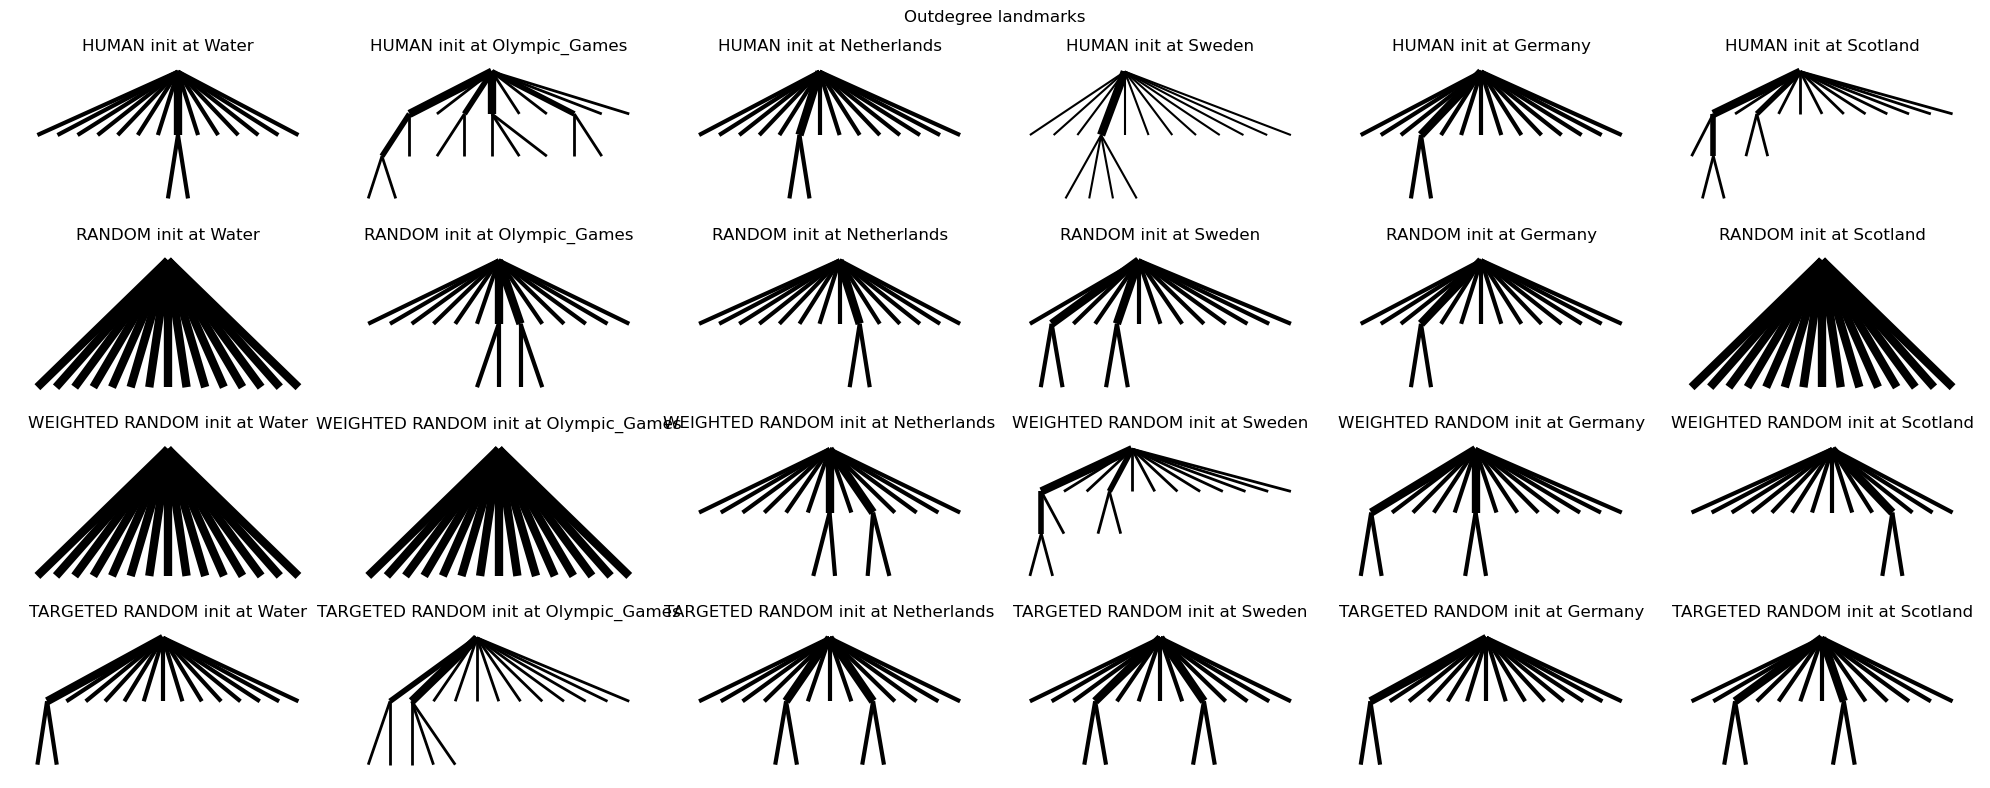

Outdegree not landmarks:


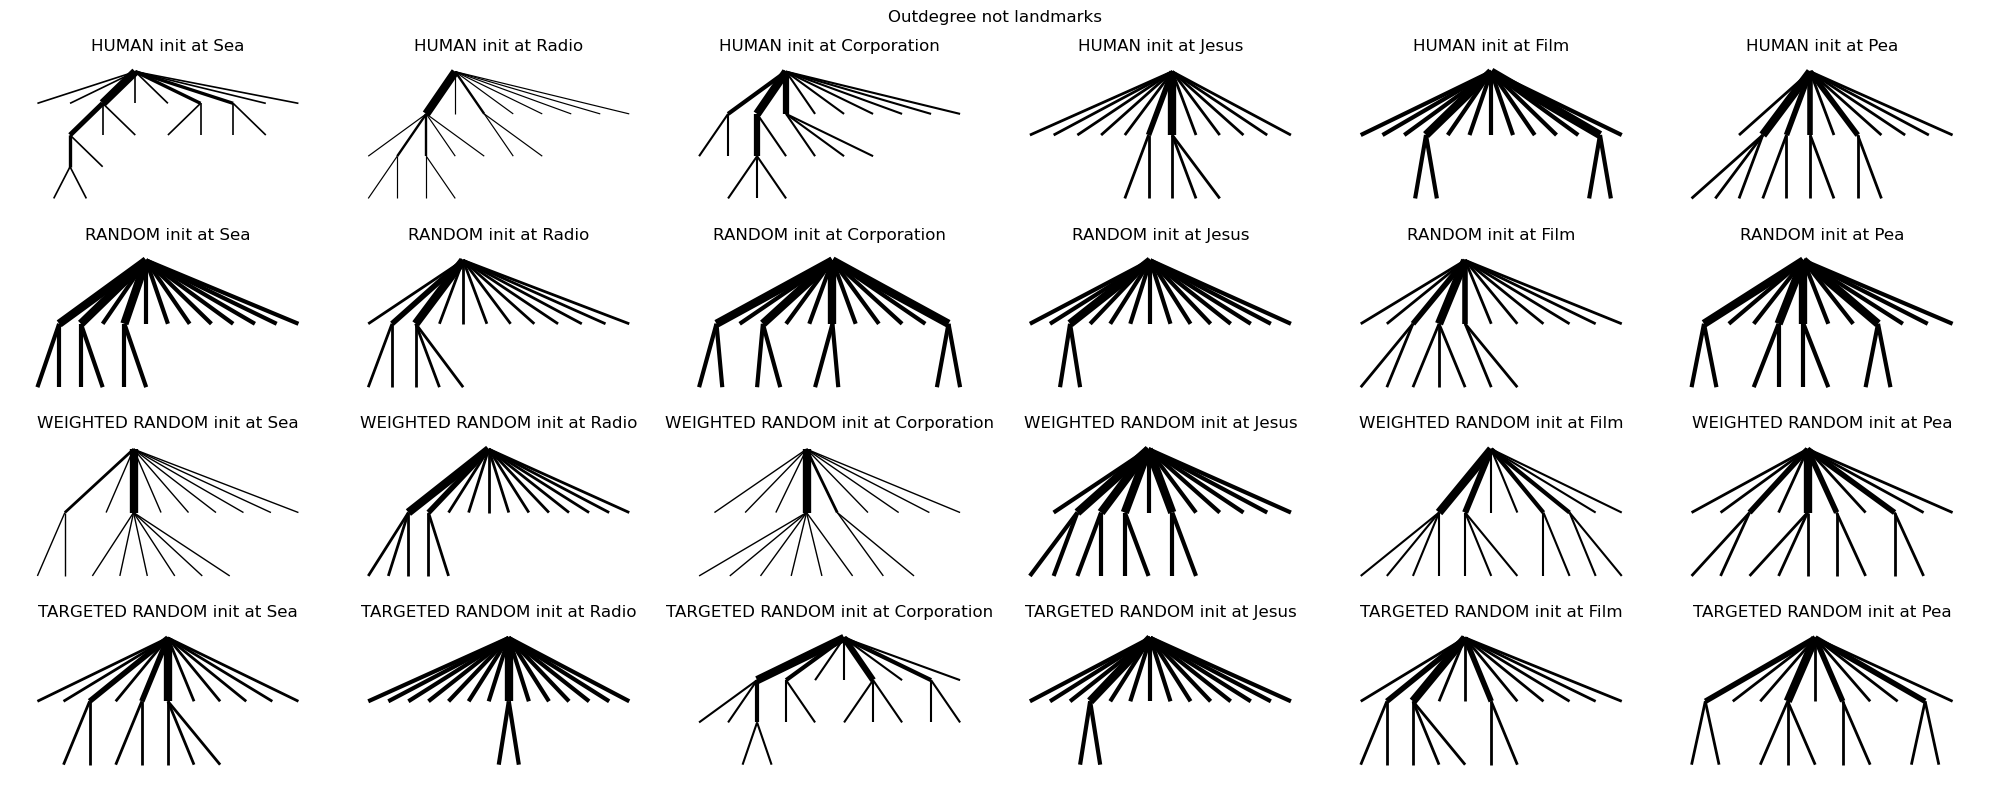

Player landmarks:


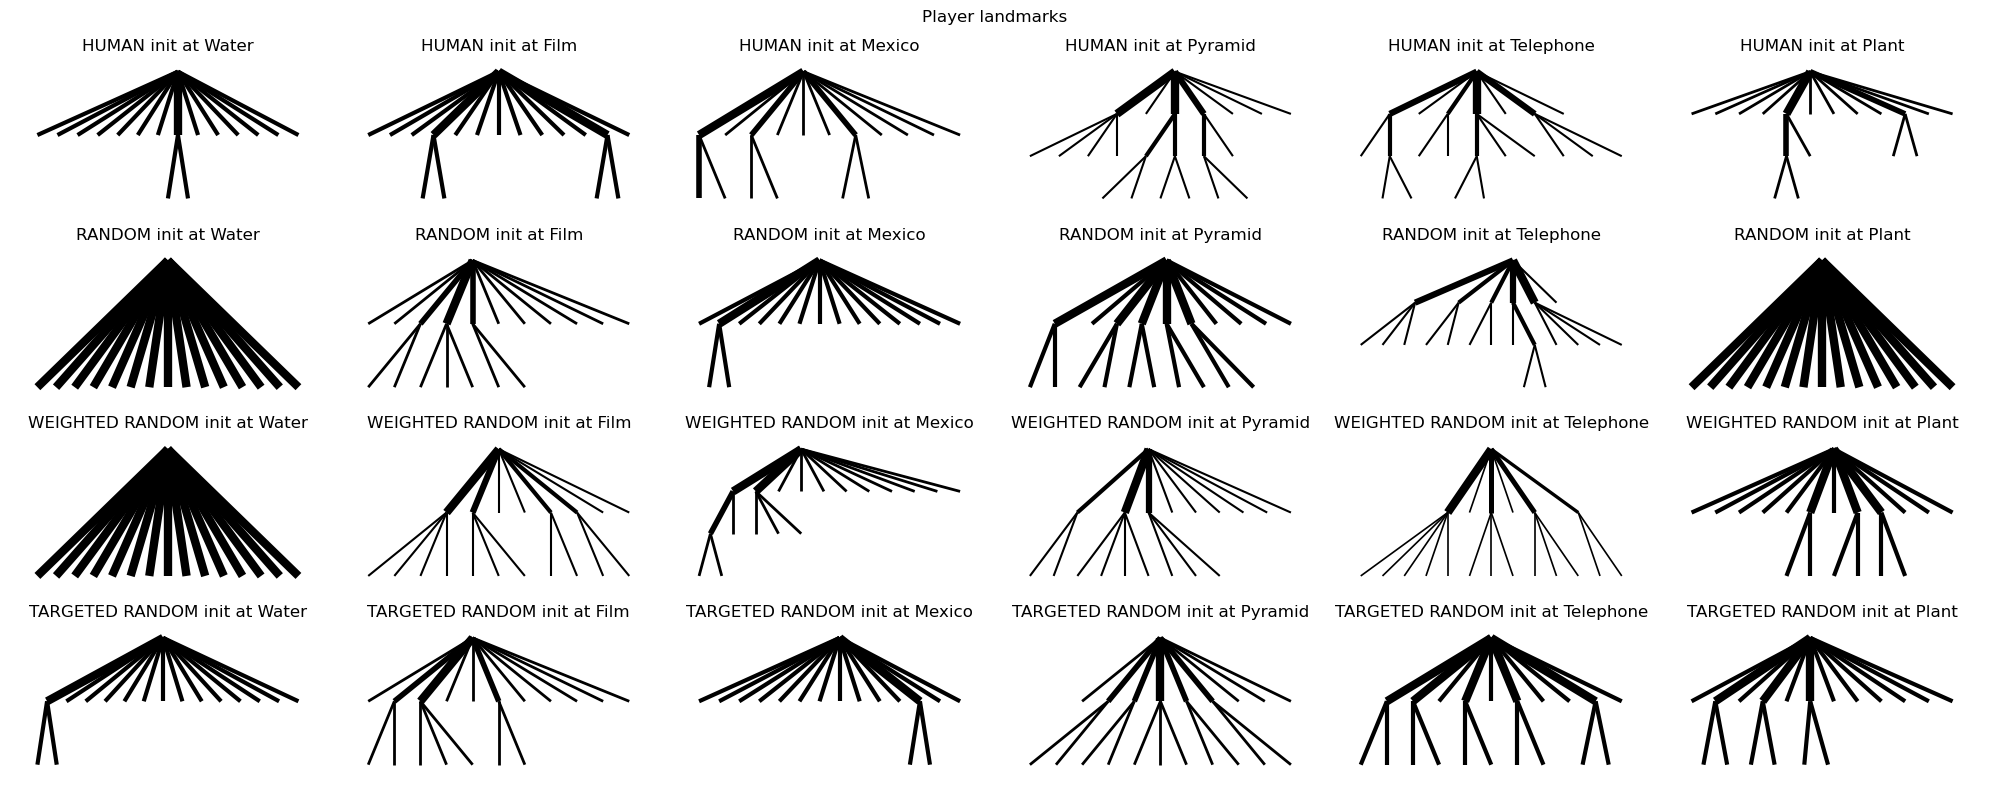

player not landmarks:


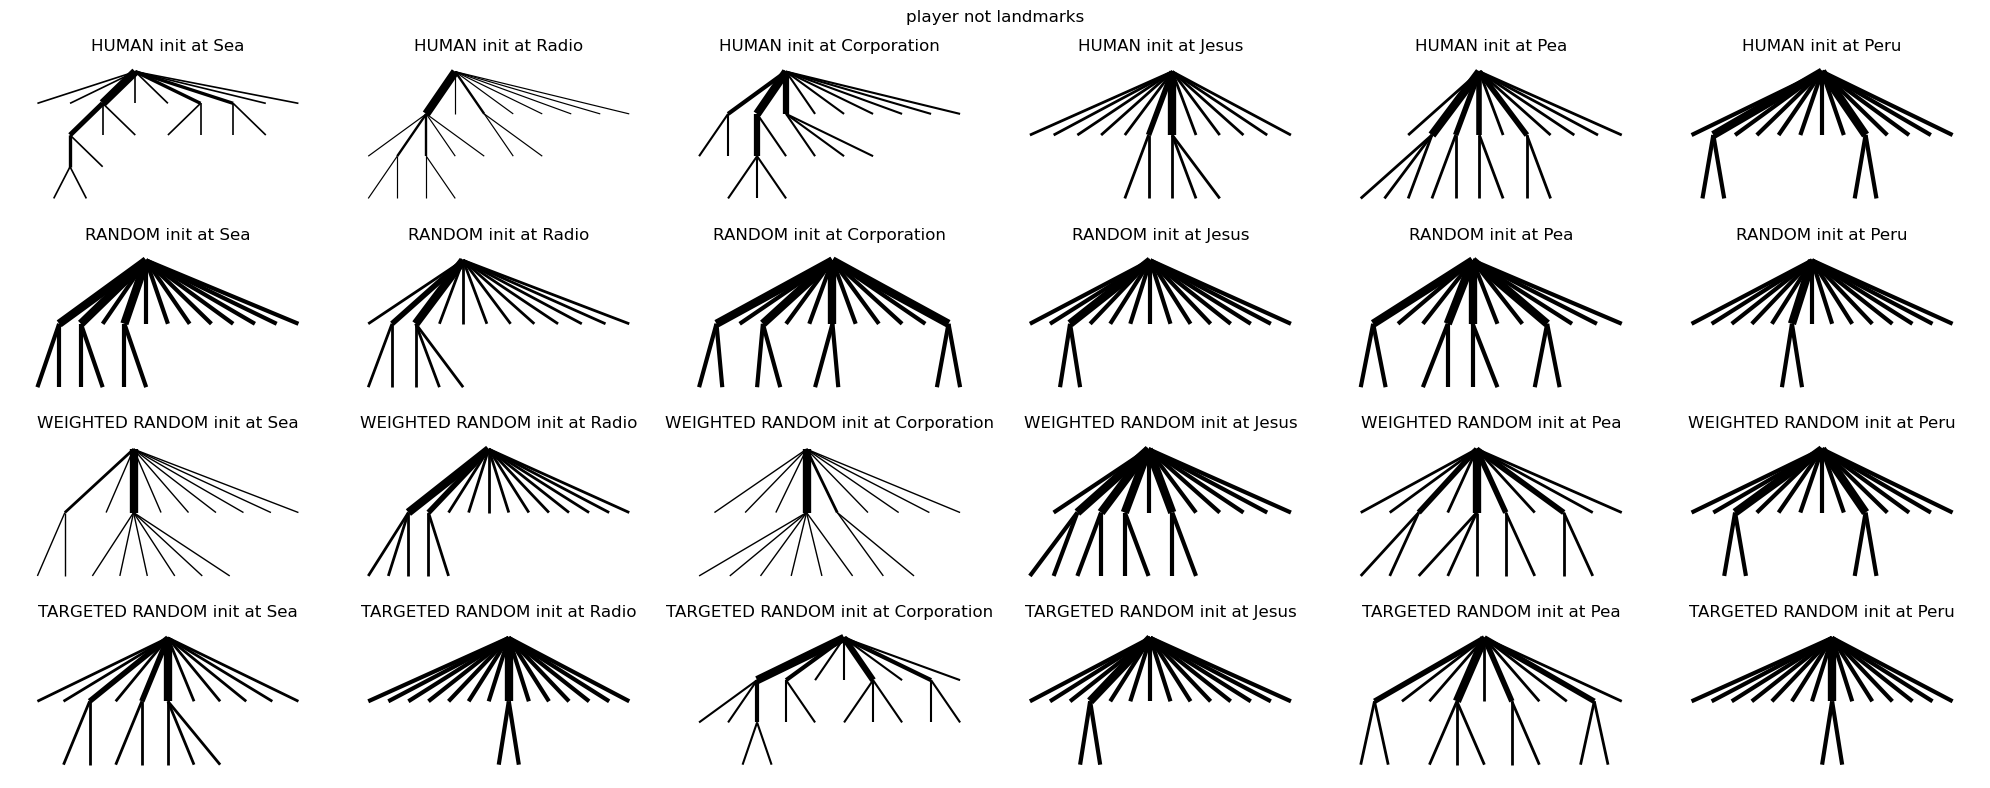

Semantic landmarks:


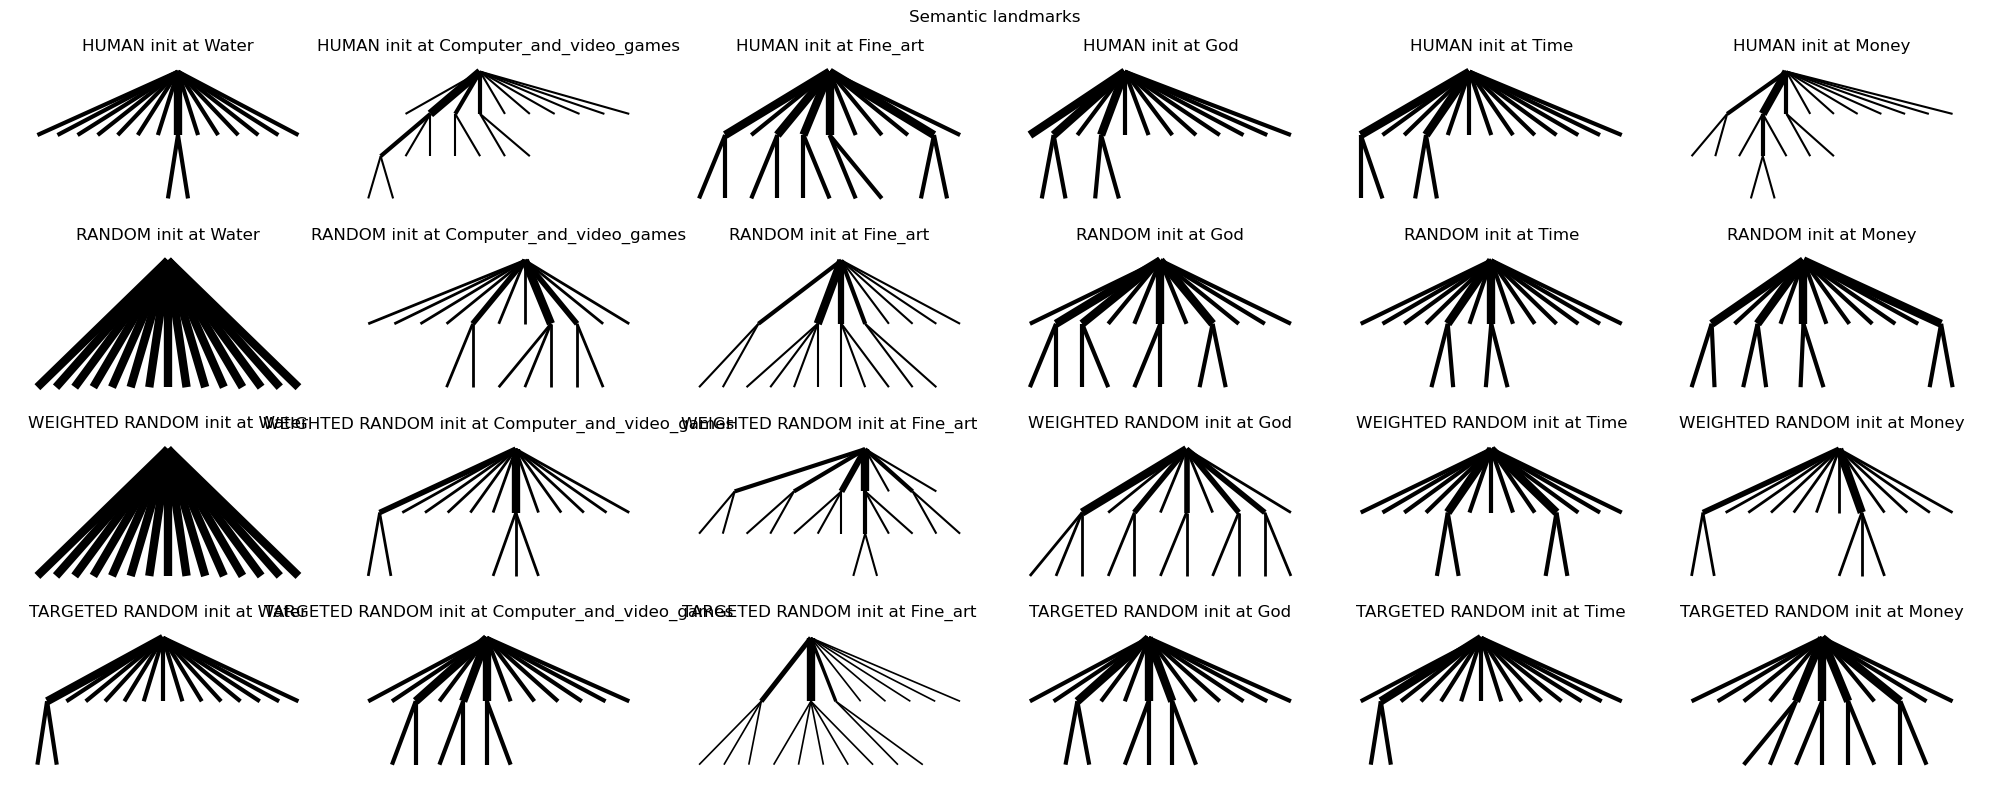

semantic not landmarks:


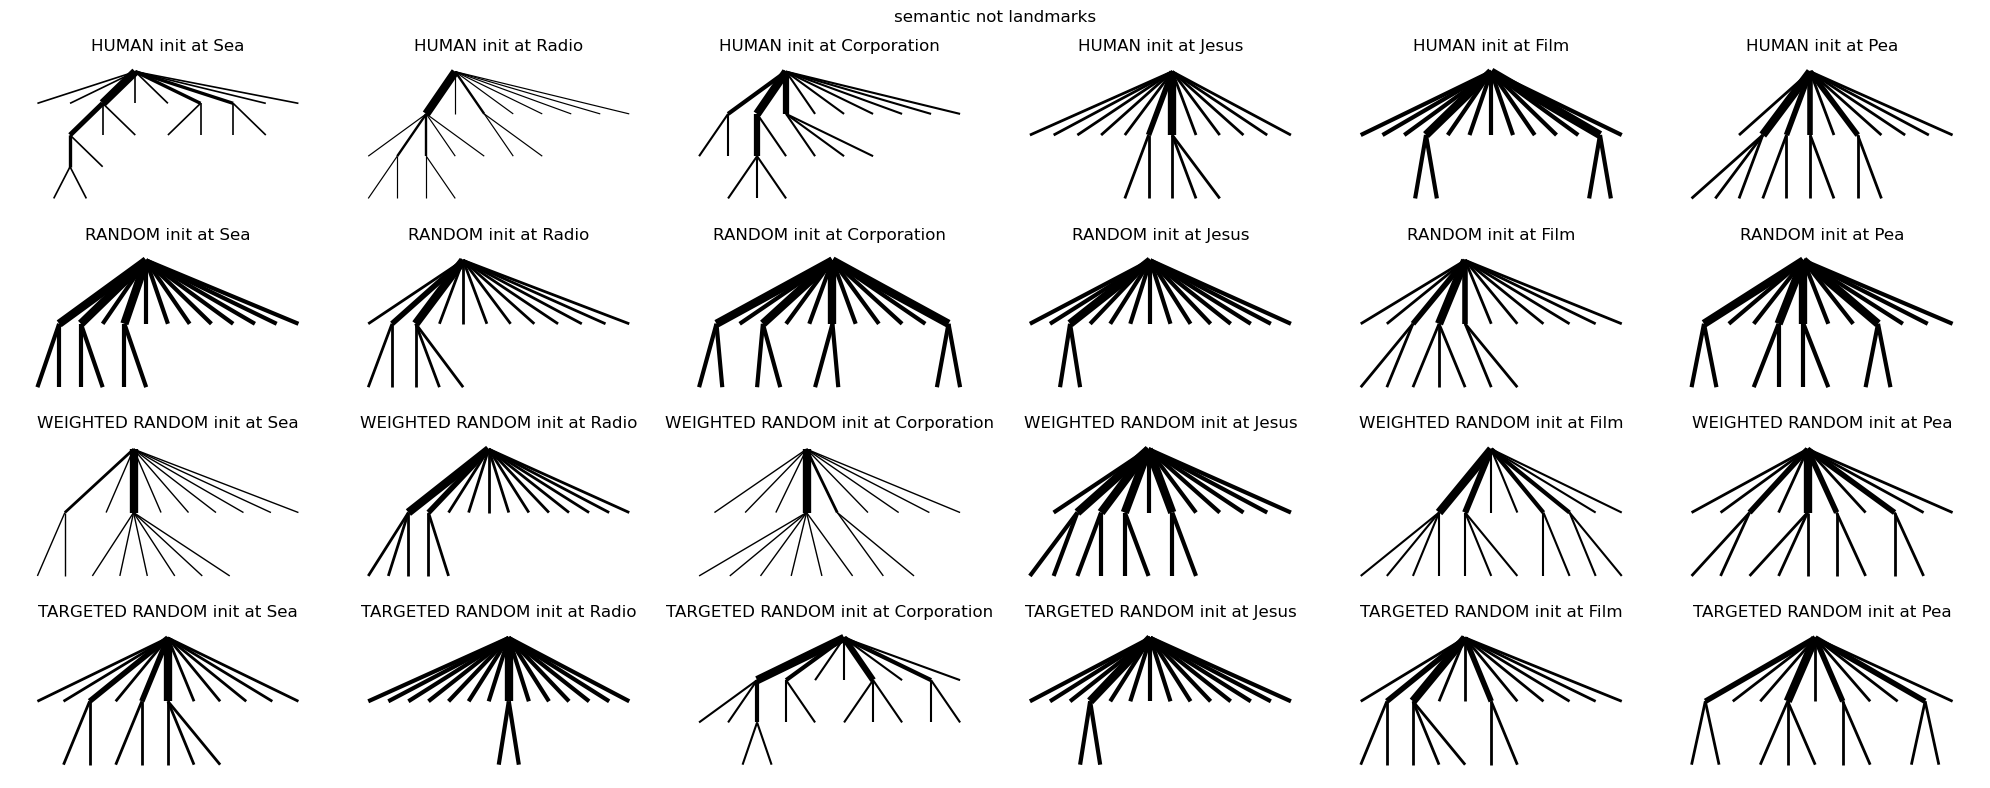

In [40]:
print("Outdegree landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in outdegree_landmarks},
    title_str="Outdegree landmarks",
)
print("Outdegree not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - outdegree_landmarks)
    },
    title_str="Outdegree not landmarks",
)
print("Player landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in player_landmarks},
    title_str="Player landmarks",
)
print("player not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - player_landmarks)
    },
    title_str="player not landmarks",
)
print("Semantic landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in semantic_landmarks},
    title_str="Semantic landmarks",
)
print("semantic not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - semantic_landmarks)
    },
    title_str="semantic not landmarks",
)
